# Database Layer

## 1. Introduction

This notebook implements the database and processing layers for the multimodal archive retrieval system.

The objective of this notebook is to address the problem of ingesting, processing, indexing, and retrieving multimodal archival content while ensuring data privacy and security. The implementation focuses on:

- Multimodal document ingestion
- Metadata normalization
- Embedding generation
- Vector database indexing
- Knowledge graph construction
- Sensitive data detection and masking
- Secure document retrieval

The system is designed to support large-scale digital archives commonly found in corporations, universities, media agencies, and enterprise knowledge management systems.

To simulate a realistic multimodal archival environment, the following datasets are selected:

| Dataset | Purpose |
|---|---|
| MediaSum | Transcript and dialogue archive |
| CNN/DailyMail | News and article archive |
| MSR-VTT | Video and multimedia archive |
| DocVQA | OCR-scanned document archive |

These datasets provide heterogeneous content types including long-form text, OCR documents, transcripts, and multimedia metadata, allowing the system to evaluate retrieval and security mechanisms under realistic archival conditions.

### TODO
- Full multimodal embedding fusion
- Video feature extraction
- Image embedding support
- Query-aware masking policies
- Access-control-aware retrieval
- Hybrid retrieval optimization
- Large-scale evaluation framework

### 1.1. Install and Import Libraries

In [1]:
# !pip install -q --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
# !pip install -q python-dotenv qdrant-client neo4j datasets huggingface_hub tqdm pandas numpy matplotlib pillow
# !pip install -q pytesseract
# !pip install -q -U FlagEmbedding
# !pip install -q gliner


In [2]:
# ============================================
# 1. Standard Library
# ============================================
import base64
import json
import os
import platform
import random
import re
import shutil
import time
from dataclasses import asdict
from itertools import islice
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

# ============================================
# 2. Third-Party Libraries
# ============================================

# --- Data Handling & Analysis ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from tqdm.auto import tqdm
import torch

# --- Image Processing / OCR ---
from PIL import Image

try:
    import pytesseract
except ImportError:
    pytesseract = None
    print("pytesseract is not available. OCR extraction will be implemented later.")

# --- Vector Database (Qdrant) ---
from qdrant_client import QdrantClient
from qdrant_client.http import models

# --- Information Extraction Models ---
try:
    from gliner import GLiNER
except ImportError:
    GLiNER = None
    print("GLiNER is not installed. Mention extraction cells will require: pip install gliner")

# --- Graph Database (Neo4j) ---
from neo4j import GraphDatabase

# --- Authentication / Environment ---
from dotenv import load_dotenv
from huggingface_hub import login, snapshot_download

# ============================================
# 3. Project Modules
# ============================================
from src.bge_m3_embedding import (
    BGE_M3_DENSE_VECTOR_SIZE,
    BGE_M3_MODEL_NAME,
    BGEM3Embedder,
    batched,
    build_qdrant_points,
    qdrant_point_ids,
)

from src.archive_schema import (
    CSV_CACHE_DIR,
    CSV_JSON_COLUMNS,
    AccessLevel,
    ArchiveChunk,
    ArchiveDocument,
    DatasetName,
    Modality,
    SensitiveEntity,
    SensitivityLevel,
    apply_security_masking_placeholder,
    archive_chunk_to_qdrant_payload,
    archive_chunks_to_dataframe,
    archive_documents_to_dataframe,
    build_embedding_text,
    chunk_text_by_words,
    csv_to_dataframe,
    dataframe_to_csv,
    jsonl_to_dataframe,
    dataframe_to_jsonl,
    dataset_cache_paths,
    json_parse_cell,
    normalize_text,
    stable_id,
)


from src.graph_kb_skeleton import (
    GRAPH_EXPORT_DIR,
    build_archive_skeleton_tables,
    export_archive_skeleton_tables,
)

from src.evaluation_metrics import (
    collect_mention_mismatches,
    evaluate_mention_records,
    filter_predictions_by_score,
    summarize_mention_mismatches,
    tune_mention_thresholds,
)

from src.graph_kb_mentions import (
    MENTION_EXPORT_DIR,
    build_mention_tables,
    export_mention_tables,
)
# ============================================
# 4. Load Environment Variables
# ============================================
load_dotenv()

True

### 1.2. Environment Setup & Service Initialization

In [3]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

#### 1.2.1. Google Colab Setup

Run this section if you are running this notebook on Google Colab. Otherwise, run section 1.3.2.

In [4]:
# from google.colab import userdata

In [5]:
# QDRANT_CLUSTER_URL = userdata.get("QDRANT_CLUSTER_URL")
# QDRANT_CLUSTER_API_KEY = userdata.get("QDRANT_CLUSTER_API_KEY")
# COLLECTION_NAME = "archive-chunks"

In [6]:
# qdrant_client = QdrantClient(
#     url=QDRANT_CLUSTER_URL,
#     api_key=QDRANT_CLUSTER_API_KEY,
# )

# print(qdrant_client.get_collections())

In [7]:
# NEO4J_URI = userdata.get("NEO4J_URI")
# NEO4J_USER = userdata.get("NEO4J_USER")
# NEO4J_PASSWORD = userdata.get("NEO4J_PASSWORD")

# driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
# driver.verify_connectivity()

#### 1.2.2. Local Setup

In [8]:
QDRANT_CLUSTER_URL = os.getenv("QDRANT_CLUSTER_URL")
QDRANT_CLUSTER_API_KEY = os.getenv("QDRANT_CLUSTER_API_KEY")
COLLECTION_NAME = "archive-chunks"

In [9]:
qdrant_client = QdrantClient(
    url=QDRANT_CLUSTER_URL,
    api_key=QDRANT_CLUSTER_API_KEY,
)

print(qdrant_client.get_collections())

collections=[CollectionDescription(name='archive-chunks')]


In [10]:
# NEO4J_URI = os.getenv("NEO4J_URI")
# NEO4J_USER = os.getenv("NEO4J_USER")
# NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")

# driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
# driver.verify_connectivity()

### 1.3. Configure Tesseract

Tesseract's installation path varies depending on the operating system (Windows, macOS, Linux), and the notebook must explicitly point to the correct binary location.

Proper configuration ensures that OCR runs reliably across different environments before we begin extracting text for RAG preprocessing.

In [11]:
def configure_tesseract(required: bool = False) -> bool:
    """Configure Tesseract when available; return whether OCR is ready."""
    if pytesseract is None:
        print("pytesseract is not installed. OCR extraction will be skipped.")
        return False

    system = platform.system()
    print(f"Detected OS: {system}")

    possible_paths = []
    install_message = "Install Tesseract and ensure it is available on PATH."

    if system == "Windows":
        possible_paths = [
            r"C:\Program Files\Tesseract-OCR\tesseract.exe",
            r"C:\Program Files (x86)\Tesseract-OCR\tesseract.exe",
        ]
        install_message = "Tesseract not found on Windows. Install from: https://github.com/UB-Mannheim/tesseract/wiki"
    elif system == "Linux":
        install_message = "Tesseract not found on Linux. Install with: sudo apt install tesseract-ocr"
    elif system == "Darwin":
        possible_paths = [
            "/usr/local/bin/tesseract",
            "/opt/homebrew/bin/tesseract",
        ]
        install_message = "Install Tesseract on macOS using: brew install tesseract"
    else:
        message = f"Unsupported OS for automatic Tesseract configuration: {system}"
        if required:
            raise OSError(message)
        print(message)
        return False

    for candidate in possible_paths:
        if os.path.exists(candidate):
            pytesseract.pytesseract.tesseract_cmd = candidate
            print(f"Using Tesseract at: {candidate}")
            return True

    found = shutil.which("tesseract")
    if found:
        pytesseract.pytesseract.tesseract_cmd = found
        print(f"Using Tesseract from PATH: {found}")
        return True

    if required:
        raise FileNotFoundError(install_message)

    print(f"{install_message} OCR extraction will be skipped for now.")
    return False

In [12]:
TESSERACT_READY = configure_tesseract()

if TESSERACT_READY and pytesseract is not None:
    print(f"Tesseract OCR ready: {pytesseract.get_tesseract_version()}")
else:
    print("Tesseract OCR is not ready; DocVQA will use the OCR-unavailable fallback text.")

Detected OS: Windows
Using Tesseract at: C:\Program Files\Tesseract-OCR\tesseract.exe
Tesseract OCR ready: 5.5.0.20241111


## 2. Data Preparation

### 2.1. MediaSum

MediaSum is used as the transcript/dialogue archive. The original Hugging Face dataset is `ccdv/mediasum`, but that repository depends on a legacy dataset loading script (`mediasum.py`). Current versions of `datasets` no longer execute remote dataset scripts, so this notebook loads the auto-converted parquet files from `nbroad/mediasum` instead.

The loader uses explicit pinned parquet file paths with the generic `parquet` builder. This avoids both the original dataset script and any script metadata in the mirror repository. The mirror exposes raw transcript turns as `utt` plus speaker labels as `speaker`, so the adapter below reconstructs a transcript-style `raw_text` field while preserving source metadata such as program, date, URL, and title.

By default, this notebook loads the full selected split. For quick tests, set `MEDIASUM_SAMPLE_SIZE` to a small integer.

In [13]:
MEDIASUM_CANONICAL_DATASET_NAME = "ccdv/mediasum"
MEDIASUM_DATASET_NAME = "nbroad/mediasum"
MEDIASUM_PARQUET_REVISION = "b56400644251d1aca3ce857dc6fb7e28fde60bc5"
MEDIASUM_PARQUET_BASE_URI = f"hf://datasets/{MEDIASUM_DATASET_NAME}@{MEDIASUM_PARQUET_REVISION}/mediasum"
MEDIASUM_SPLIT = "train"
MEDIASUM_SAMPLE_SIZE: Optional[int] = None  # Set to a small number for quick tests.
USE_STREAMING = True


def mediasum_parquet_data_files(split: str = MEDIASUM_SPLIT) -> Dict[str, Any]:
    """Return explicit parquet files so `datasets` never tries to execute mediasum.py."""
    if split == "train":
        return {
            split: [
                f"{MEDIASUM_PARQUET_BASE_URI}/mediasum-train-{index:05d}-of-00009.parquet"
                for index in range(9)
            ]
        }

    if split in {"validation", "test"}:
        return {split: f"{MEDIASUM_PARQUET_BASE_URI}/mediasum-{split}.parquet"}

    raise ValueError(f"Unsupported MediaSum split: {split}")


def load_mediasum_sample(
    sample_size: Optional[int] = MEDIASUM_SAMPLE_SIZE,
    split: str = MEDIASUM_SPLIT,
    streaming: bool = USE_STREAMING,
) -> pd.DataFrame:
    """Download/read MediaSum records from script-free parquet files.

    Set sample_size=None to load the full selected split.
    """
    data_files = mediasum_parquet_data_files(split)

    if streaming:
        dataset_iter = load_dataset(
            "parquet",
            data_files=data_files,
            split=split,
            streaming=True,
        )
        records = list(dataset_iter if sample_size is None else islice(dataset_iter, sample_size))
    else:
        split_expr = split if sample_size is None else f"{split}[:{sample_size}]"
        dataset = load_dataset(
            "parquet",
            data_files=data_files,
            split=split_expr,
        )
        records = list(dataset)

    return pd.DataFrame(records)


# mediasum_df = load_mediasum_sample()
# print(f"Loaded MediaSum records: {len(mediasum_df):,}")
# print(f"Columns: {list(mediasum_df.columns)}")
# mediasum_df.head()

In [14]:
def build_mediasum_transcript_text(record: Dict[str, Any]) -> str:
    """Extract transcript text from either the old script format or parquet mirror."""
    document = record.get("document")
    if document:
        return normalize_text(document)

    utterances = record.get("utt") or record.get("utterances") or []
    speakers = record.get("speaker") or record.get("speakers") or []

    if not isinstance(utterances, list):
        return normalize_text(utterances)

    lines = []
    for index, utterance in enumerate(utterances):
        utterance_text = normalize_text(utterance)
        if not utterance_text:
            continue

        speaker = None
        if isinstance(speakers, list) and index < len(speakers):
            speaker = normalize_text(speakers[index])

        if speaker:
            lines.append(f"{speaker}: {utterance_text}")
        else:
            lines.append(utterance_text)

    return normalize_text("\n".join(lines))


def mediasum_record_to_document(record: Dict[str, Any]) -> ArchiveDocument:
    source_id = str(record.get("id", "")).strip()
    raw_text = build_mediasum_transcript_text(record)
    summary = normalize_text(record.get("summary", ""))
    title = normalize_text(record.get("title", ""))

    if not source_id:
        source_id = stable_id(DatasetName.MEDIASUM.value, raw_text[:500], summary[:200])

    document_id = stable_id(DatasetName.MEDIASUM.value, source_id)

    return ArchiveDocument(
        document_id=document_id,
        source_id=source_id,
        dataset=DatasetName.MEDIASUM.value,
        modality=Modality.TRANSCRIPT.value,
        title=title or f"MediaSum Transcript {source_id}",
        raw_text=raw_text,
        summary=summary,
        source_metadata={
            "canonical_hf_dataset": MEDIASUM_CANONICAL_DATASET_NAME,
            "hf_dataset": MEDIASUM_DATASET_NAME,
            "hf_revision": MEDIASUM_PARQUET_REVISION,
            "hf_split": MEDIASUM_SPLIT,
            "program": record.get("program"),
            "date": record.get("date"),
            "url": record.get("url"),
            "title": title or None,
            "original_fields": list(record.keys()),
        },
    )


def document_to_archive_chunks(
    document: ArchiveDocument,
    max_words: int = 350,
    overlap_words: int = 60,
) -> List[ArchiveChunk]:
    raw_chunks = chunk_text_by_words(
        document.raw_text,
        max_words=max_words,
        overlap_words=overlap_words,
    )

    chunks: List[ArchiveChunk] = []

    for chunk_index, raw_chunk in enumerate(raw_chunks):
        masked_text, sensitive_entities, sensitivity_level, access_level = apply_security_masking_placeholder(raw_chunk)
        chunk_id = stable_id(document.document_id, chunk_index, raw_chunk[:200])

        embedding_text = build_embedding_text(
            dataset=document.dataset,
            modality=document.modality,
            title=document.title,
            summary=document.summary,
            masked_text=masked_text,
            source_metadata=document.source_metadata,
        )

        chunks.append(
            ArchiveChunk(
                chunk_id=chunk_id,
                document_id=document.document_id,
                source_id=document.source_id,
                dataset=document.dataset,
                modality=document.modality,
                chunk_index=chunk_index,
                title=document.title,
                raw_text=raw_chunk,
                masked_text=masked_text,
                embedding_text=embedding_text,
                summary=document.summary,
                sensitivity_level=sensitivity_level,
                sensitive_entities=sensitive_entities,
                access_level=access_level,
                source_metadata=document.source_metadata,
            )
        )

    return chunks

In [15]:
# mediasum_records = mediasum_df.to_dict(orient="records")
# mediasum_documents = [mediasum_record_to_document(record) for record in mediasum_records]

# mediasum_chunks: List[ArchiveChunk] = []
# for document in tqdm(mediasum_documents, desc="Chunking MediaSum documents"):
#     mediasum_chunks.extend(document_to_archive_chunks(document))

# mediasum_document_df = archive_documents_to_dataframe(mediasum_documents)
# mediasum_chunk_df = archive_chunks_to_dataframe(mediasum_chunks)
# mediasum_document_csv_path, mediasum_chunk_csv_path = dataset_cache_paths("mediasum")
# dataframe_to_csv(mediasum_document_df, mediasum_document_csv_path, json_columns=["source_metadata"])
# dataframe_to_csv(mediasum_chunk_df, mediasum_chunk_csv_path, json_columns=CSV_JSON_COLUMNS)

# print(f"Documents: {len(mediasum_documents):,}")
# print(f"Chunks: {len(mediasum_chunks):,}")


In [16]:
if "_load_archive_chunks_from_csv" not in globals():
    def _chunk_dataframe_to_archive_chunks(chunk_df: pd.DataFrame) -> List[ArchiveChunk]:
        chunk_df = chunk_df.copy()

        if "chunk_index" in chunk_df.columns:
            chunk_df["chunk_index"] = pd.to_numeric(chunk_df["chunk_index"], errors="coerce").fillna(0).astype(int)

        for column in ["dense_vector_ready", "sparse_vector_ready"]:
            if column in chunk_df.columns:
                chunk_df[column] = chunk_df[column].map(
                    lambda value: str(value).strip().lower() == "true"
                    if isinstance(value, str)
                    else bool(value)
                )

        chunk_df = chunk_df.where(pd.notna(chunk_df), None)
        return [ArchiveChunk(**record) for record in chunk_df.to_dict(orient="records")]


    def _read_chunk_csv_dataframe(
        csv_path: os.PathLike[str] | str,
        max_bytes: Optional[int] = None,
        chunksize: int = 50_000,
    ) -> pd.DataFrame:
        if max_bytes is None:
            return csv_to_dataframe(csv_path, json_columns=CSV_JSON_COLUMNS)

        frames = []
        loaded_bytes = 0

        for chunk_df in pd.read_csv(csv_path, chunksize=chunksize):
            chunk_bytes = int(chunk_df.memory_usage(index=True, deep=True).sum())
            remaining_bytes = max_bytes - loaded_bytes

            if chunk_bytes > remaining_bytes:
                average_row_bytes = max(chunk_bytes / max(len(chunk_df), 1), 1)
                rows_to_keep = max(int(remaining_bytes // average_row_bytes), 0)
                if rows_to_keep > 0:
                    chunk_df = chunk_df.iloc[:rows_to_keep].copy()
                    frames.append(chunk_df)
                    loaded_bytes += int(chunk_df.memory_usage(index=True, deep=True).sum())
                break

            frames.append(chunk_df)
            loaded_bytes += chunk_bytes

            if loaded_bytes >= max_bytes:
                break

        if not frames:
            return pd.DataFrame()

        chunk_df = pd.concat(frames, ignore_index=True)
        for column in CSV_JSON_COLUMNS:
            if column in chunk_df.columns:
                chunk_df[column] = chunk_df[column].map(json_parse_cell)

        print(f"Loaded approximately {loaded_bytes / (1024 ** 3):.2f} GiB from {csv_path}")
        return chunk_df


    def _load_archive_chunks_from_csv(
        csv_path: os.PathLike[str] | str,
        max_bytes: Optional[int] = None,
    ) -> Tuple[pd.DataFrame, List[ArchiveChunk]]:
        chunk_df = _read_chunk_csv_dataframe(csv_path, max_bytes=max_bytes)
        chunks = _chunk_dataframe_to_archive_chunks(chunk_df)
        print(f"Loaded chunks from CSV: {len(chunks):,}")
        return chunk_df, chunks


CHUNK_CSV_READ_LIMIT_BYTES = 1 * 1024 ** 3

_, mediasum_chunk_csv_path = dataset_cache_paths("mediasum")
mediasum_chunk_df, mediasum_chunks = _load_archive_chunks_from_csv(
    mediasum_chunk_csv_path,
    max_bytes=CHUNK_CSV_READ_LIMIT_BYTES,
)


Loaded approximately 1.00 GiB from data\csv_cache\mediasum_chunks.csv
Loaded chunks from CSV: 134,817


In [17]:
preview_columns = [
    "chunk_id",
    "document_id",
    "dataset",
    "modality",
    "chunk_index",
    "sensitivity_level",
    "access_level",
    "raw_text",
    "masked_text",
]

mediasum_chunk_df[preview_columns].head()


,chunk_id,document_id,dataset,modality,chunk_index,sensitivity_level,access_level,raw_text,masked_text
0,016ab6e11ff9ec666f56855b,5c7aa6d2035899720d170b77,mediasum,transcript,0,S0,public,"FARAI CHIDEYA, host: Now, moving on, Forest Wh...","FARAI CHIDEYA, host: Now, moving on, Forest Wh..."
1,d29c6ca56395d6633221b335,5c7aa6d2035899720d170b77,mediasum,transcript,1,S0,public,"Mr. KYLE BOWSER (Co-producer, ""The Bible Exper...","Mr. KYLE BOWSER (Co-producer, ""The Bible Exper..."
2,86da10fbe86ac8596bf56dce,5c7aa6d2035899720d170b77,mediasum,transcript,2,S0,public,Ms. WENDY RAQUEL ROBINSON (Actress): (As Angel...,Ms. WENDY RAQUEL ROBINSON (Actress): (As Angel...
3,7995a80c7aac78cd846121b1,5c7aa6d2035899720d170b77,mediasum,transcript,3,S0,public,"FARAI CHIDEYA, host: …and podcasting, listenin...","FARAI CHIDEYA, host: …and podcasting, listenin..."
4,9af0e273553ced784b1bc73b,5c7aa6d2035899720d170b77,mediasum,transcript,4,S0,public,"Mr. KYLE BOWSER (Co-producer, ""The Bible Exper...","Mr. KYLE BOWSER (Co-producer, ""The Bible Exper..."


In [18]:
# Inspect one future embedding input.
# This should use masked_text, not raw_text, once the masking layer is implemented.
print(mediasum_chunks[0].embedding_text[:2_000])

Dataset: mediasum
Modality: transcript
Title: Black Actors Give Bible Star Appeal
Summary: More than 400 black actors, artists and ministers are bringing the Gospel to life in the audio book, The Bible Experience:The Complete Bible. Farai Chideya talks with producer Kyle Bowser and actress Wendy Raquel Robinson, who lends her voice to the project.
Metadata: {"canonical_hf_dataset": "ccdv/mediasum", "hf_dataset": "nbroad/mediasum", "hf_revision": "b56400644251d1aca3ce857dc6fb7e28fde60bc5", "hf_split": "train", "program": "News & Notes", "date": "2007-11-28", "url": "https://www.npr.org/templates/story/story.php?storyId=16697288", "title": "Black Actors Give Bible Star Appeal", "original_fields": ["id", "program", "date", "url", "title", "summary", "utt", "speaker"]}
Content: FARAI CHIDEYA, host: Now, moving on, Forest Whitaker as Moses, Tisha Campbell Martin as Mary Magdalene - well, that's all in "The Bible Experience." A New Testament edition was released in 2006. This edition is bill

### 2.2. CNN/DailyMail

CNN/DailyMail is used as the news/article archive. The Hugging Face dataset `abisee/cnn_dailymail` is parquet-backed and provides three main fields: `id`, `article`, and `highlights`.

By default, this notebook loads the full selected split from version `3.0.0`. Each article is converted into the common `ArchiveDocument` schema, with the article body stored as `raw_text` and the highlights stored as `summary`.

In [19]:
CNN_DAILYMAIL_DATASET_NAME = "abisee/cnn_dailymail"
CNN_DAILYMAIL_CONFIG = "3.0.0"
CNN_DAILYMAIL_SPLIT = "train"
CNN_DAILYMAIL_SAMPLE_SIZE: Optional[int] = None  # Set to a small number for quick tests.
CNN_DAILYMAIL_USE_STREAMING = True


def load_cnn_dailymail_sample(
    sample_size: Optional[int] = CNN_DAILYMAIL_SAMPLE_SIZE,
    split: str = CNN_DAILYMAIL_SPLIT,
    config: str = CNN_DAILYMAIL_CONFIG,
    streaming: bool = CNN_DAILYMAIL_USE_STREAMING,
) -> pd.DataFrame:
    """Download/read CNN/DailyMail records from Hugging Face.

    Set sample_size=None to load the full selected split.
    """
    if streaming:
        dataset_iter = load_dataset(
            CNN_DAILYMAIL_DATASET_NAME,
            config,
            split=split,
            streaming=True,
        )
        records = list(dataset_iter if sample_size is None else islice(dataset_iter, sample_size))
    else:
        split_expr = split if sample_size is None else f"{split}[:{sample_size}]"
        dataset = load_dataset(
            CNN_DAILYMAIL_DATASET_NAME,
            config,
            split=split_expr,
        )
        records = list(dataset)

    return pd.DataFrame(records)


# cnn_dailymail_df = load_cnn_dailymail_sample()
# print(f"Loaded CNN/DailyMail records: {len(cnn_dailymail_df):,}")
# print(f"Columns: {list(cnn_dailymail_df.columns)}")
# cnn_dailymail_df.head()

In [20]:
def cnn_dailymail_record_to_document(record: Dict[str, Any]) -> ArchiveDocument:
    source_id = str(record.get("id", "")).strip()
    raw_text = normalize_text(record.get("article", ""))
    summary = normalize_text(record.get("highlights", ""))

    if not source_id:
        source_id = stable_id(DatasetName.CNN_DAILYMAIL.value, raw_text[:500], summary[:200])

    document_id = stable_id(DatasetName.CNN_DAILYMAIL.value, source_id)
    title = f"CNN/DailyMail Article {source_id[:12]}"

    return ArchiveDocument(
        document_id=document_id,
        source_id=source_id,
        dataset=DatasetName.CNN_DAILYMAIL.value,
        modality=Modality.ARTICLE.value,
        title=title,
        raw_text=raw_text,
        summary=summary,
        source_metadata={
            "hf_dataset": CNN_DAILYMAIL_DATASET_NAME,
            "hf_config": CNN_DAILYMAIL_CONFIG,
            "hf_split": CNN_DAILYMAIL_SPLIT,
            "original_fields": list(record.keys()),
        },
    )


def cnn_dailymail_document_to_archive_chunks(
    document: ArchiveDocument,
    max_words: int = 350,
    overlap_words: int = 60,
) -> List[ArchiveChunk]:
    raw_chunks = chunk_text_by_words(
        document.raw_text,
        max_words=max_words,
        overlap_words=overlap_words,
    )

    chunks: List[ArchiveChunk] = []

    for chunk_index, raw_chunk in enumerate(raw_chunks):
        masked_text, sensitive_entities, sensitivity_level, access_level = apply_security_masking_placeholder(raw_chunk)
        chunk_id = stable_id(document.document_id, chunk_index, raw_chunk[:200])

        embedding_text = build_embedding_text(
            dataset=document.dataset,
            modality=document.modality,
            title=document.title,
            summary=document.summary,
            masked_text=masked_text,
            source_metadata=document.source_metadata,
        )

        chunks.append(
            ArchiveChunk(
                chunk_id=chunk_id,
                document_id=document.document_id,
                source_id=document.source_id,
                dataset=document.dataset,
                modality=document.modality,
                chunk_index=chunk_index,
                title=document.title,
                raw_text=raw_chunk,
                masked_text=masked_text,
                embedding_text=embedding_text,
                summary=document.summary,
                sensitivity_level=sensitivity_level,
                sensitive_entities=sensitive_entities,
                access_level=access_level,
                source_metadata=document.source_metadata,
            )
        )

    return chunks

In [21]:
# cnn_dailymail_records = cnn_dailymail_df.to_dict(orient="records")
# cnn_dailymail_documents = [cnn_dailymail_record_to_document(record) for record in cnn_dailymail_records]

# cnn_dailymail_chunks: List[ArchiveChunk] = []
# for document in tqdm(cnn_dailymail_documents, desc="Chunking CNN/DailyMail documents"):
#     cnn_dailymail_chunks.extend(cnn_dailymail_document_to_archive_chunks(document))

# cnn_dailymail_document_df = archive_documents_to_dataframe(cnn_dailymail_documents)
# cnn_dailymail_chunk_df = archive_chunks_to_dataframe(cnn_dailymail_chunks)
# cnn_dailymail_document_csv_path, cnn_dailymail_chunk_csv_path = dataset_cache_paths("cnn_dailymail")
# dataframe_to_csv(cnn_dailymail_document_df, cnn_dailymail_document_csv_path, json_columns=["source_metadata"])
# dataframe_to_csv(cnn_dailymail_chunk_df, cnn_dailymail_chunk_csv_path, json_columns=CSV_JSON_COLUMNS)

# print(f"Documents: {len(cnn_dailymail_documents):,}")
# print(f"Chunks: {len(cnn_dailymail_chunks):,}")


In [22]:
if "_load_archive_chunks_from_csv" not in globals():
    def _chunk_dataframe_to_archive_chunks(chunk_df: pd.DataFrame) -> List[ArchiveChunk]:
        chunk_df = chunk_df.copy()

        if "chunk_index" in chunk_df.columns:
            chunk_df["chunk_index"] = pd.to_numeric(chunk_df["chunk_index"], errors="coerce").fillna(0).astype(int)

        for column in ["dense_vector_ready", "sparse_vector_ready"]:
            if column in chunk_df.columns:
                chunk_df[column] = chunk_df[column].map(
                    lambda value: str(value).strip().lower() == "true"
                    if isinstance(value, str)
                    else bool(value)
                )

        chunk_df = chunk_df.where(pd.notna(chunk_df), None)
        return [ArchiveChunk(**record) for record in chunk_df.to_dict(orient="records")]


    def _read_chunk_csv_dataframe(
        csv_path: os.PathLike[str] | str,
        max_bytes: Optional[int] = None,
        chunksize: int = 50_000,
    ) -> pd.DataFrame:
        if max_bytes is None:
            return csv_to_dataframe(csv_path, json_columns=CSV_JSON_COLUMNS)

        frames = []
        loaded_bytes = 0

        for chunk_df in pd.read_csv(csv_path, chunksize=chunksize):
            chunk_bytes = int(chunk_df.memory_usage(index=True, deep=True).sum())
            remaining_bytes = max_bytes - loaded_bytes

            if chunk_bytes > remaining_bytes:
                average_row_bytes = max(chunk_bytes / max(len(chunk_df), 1), 1)
                rows_to_keep = max(int(remaining_bytes // average_row_bytes), 0)
                if rows_to_keep > 0:
                    chunk_df = chunk_df.iloc[:rows_to_keep].copy()
                    frames.append(chunk_df)
                    loaded_bytes += int(chunk_df.memory_usage(index=True, deep=True).sum())
                break

            frames.append(chunk_df)
            loaded_bytes += chunk_bytes

            if loaded_bytes >= max_bytes:
                break

        if not frames:
            return pd.DataFrame()

        chunk_df = pd.concat(frames, ignore_index=True)
        for column in CSV_JSON_COLUMNS:
            if column in chunk_df.columns:
                chunk_df[column] = chunk_df[column].map(json_parse_cell)

        print(f"Loaded approximately {loaded_bytes / (1024 ** 3):.2f} GiB from {csv_path}")
        return chunk_df


    def _load_archive_chunks_from_csv(
        csv_path: os.PathLike[str] | str,
        max_bytes: Optional[int] = None,
    ) -> Tuple[pd.DataFrame, List[ArchiveChunk]]:
        chunk_df = _read_chunk_csv_dataframe(csv_path, max_bytes=max_bytes)
        chunks = _chunk_dataframe_to_archive_chunks(chunk_df)
        print(f"Loaded chunks from CSV: {len(chunks):,}")
        return chunk_df, chunks


CHUNK_CSV_READ_LIMIT_BYTES = 1 * 1024 ** 3

_, cnn_dailymail_chunk_csv_path = dataset_cache_paths("cnn_dailymail")
cnn_dailymail_chunk_df, cnn_dailymail_chunks = _load_archive_chunks_from_csv(
    cnn_dailymail_chunk_csv_path,
    max_bytes=CHUNK_CSV_READ_LIMIT_BYTES,
)


Loaded approximately 1.00 GiB from data\csv_cache\cnn_dailymail_chunks.csv
Loaded chunks from CSV: 153,327


In [23]:
preview_columns = [
    "chunk_id",
    "document_id",
    "dataset",
    "modality",
    "chunk_index",
    "sensitivity_level",
    "access_level",
    "raw_text",
    "masked_text",
]

cnn_dailymail_chunk_df[preview_columns].head()


,chunk_id,document_id,dataset,modality,chunk_index,sensitivity_level,access_level,raw_text,masked_text
0,5309caf85802afc3e9f6d9aa,2b9c06ea12675e1a5070f338,cnn_dailymail,article,0,S0,public,"LONDON, England (Reuters) -- Harry Potter star...","LONDON, England (Reuters) -- Harry Potter star..."
1,d4f32ce2e055c21da3afd3cd,2b9c06ea12675e1a5070f338,cnn_dailymail,article,1,S0,public,"Despite his growing fame and riches, the actor...","Despite his growing fame and riches, the actor..."
2,25df6a2b3a89c0b5d8cb0df9,84c7300fd150160a8612d8c8,cnn_dailymail,article,0,S0,public,Editor's note: In our Behind the Scenes series...,Editor's note: In our Behind the Scenes series...
3,7dfc63e3766005eaa7e4f91d,84c7300fd150160a8612d8c8,cnn_dailymail,article,1,S0,public,Even though we were not exactly welcomed with ...,Even though we were not exactly welcomed with ...
4,78719743200ba890cca1c4fd,84c7300fd150160a8612d8c8,cnn_dailymail,article,2,S0,public,Leifman tells me that these prisoner-patients ...,Leifman tells me that these prisoner-patients ...


In [24]:
# Inspect one future embedding input.
# This should use masked_text, not raw_text, once the masking layer is implemented.
print(cnn_dailymail_chunks[0].embedding_text[:2_000])

Dataset: cnn_dailymail
Modality: article
Title: CNN/DailyMail Article 42c027e4ff97
Summary: Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .
Metadata: {"hf_dataset": "abisee/cnn_dailymail", "hf_config": "3.0.0", "hf_split": "train", "original_fields": ["article", "highlights", "id"]}
Content: LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him.

Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as soon as they turn 18, suddenly buy th

### 2.3. MSR-VTT

MSR-VTT is used as the video archive in a text-projected form. The Hugging Face dataset `AlexZigma/msr-vtt` is parquet-backed and provides one caption row per video segment, with fields such as `video_id`, `caption`, `sen_id`, `category`, `url`, `start time`, and `end time`.

For the current database layer, we do not ingest native video frames yet. Instead, captions and segment timing metadata are grouped by `video_id` and converted into one text document per video. Each caption becomes a timestamped segment line, allowing `chunk_text_by_words` to preserve caption/segment boundaries during chunking.

TODO:
- Add native video/frame embeddings.
- Add richer category labels.
- Add sensitive data masking.
- Add topic extraction.
- Add dense and sparse embeddings.

In [25]:
MSR_VTT_DATASET_NAME = "AlexZigma/msr-vtt"
MSR_VTT_CONFIG = "default"
MSR_VTT_SPLIT = "train"
MSR_VTT_SAMPLE_SIZE: Optional[int] = None  # Set to a small number for quick tests.
MSR_VTT_USE_STREAMING = True


def load_msr_vtt_sample(
    sample_size: Optional[int] = MSR_VTT_SAMPLE_SIZE,
    split: str = MSR_VTT_SPLIT,
    config: str = MSR_VTT_CONFIG,
    streaming: bool = MSR_VTT_USE_STREAMING,
) -> pd.DataFrame:
    """Download/read MSR-VTT caption rows from Hugging Face.

    Set sample_size=None to load the full selected split.
    """
    if streaming:
        dataset_iter = load_dataset(
            MSR_VTT_DATASET_NAME,
            config,
            split=split,
            streaming=True,
        )
        records = list(dataset_iter if sample_size is None else islice(dataset_iter, sample_size))
    else:
        split_expr = split if sample_size is None else f"{split}[:{sample_size}]"
        dataset = load_dataset(
            MSR_VTT_DATASET_NAME,
            config,
            split=split_expr,
        )
        records = list(dataset)

    return pd.DataFrame(records)


# msr_vtt_df = load_msr_vtt_sample()
# print(f"Loaded MSR-VTT caption rows: {len(msr_vtt_df):,}")
# print(f"Columns: {list(msr_vtt_df.columns)}")
# msr_vtt_df.head()

In [26]:
def format_msr_vtt_time(value: Any) -> str:
    """Format segment times consistently for text-projected video chunks."""
    try:
        return f"{float(value):.2f}s"
    except (TypeError, ValueError):
        return "unknown"


def build_msr_vtt_segment_text(row: Dict[str, Any], segment_index: int) -> str:
    caption = normalize_text(row.get("caption", ""))
    start_time = format_msr_vtt_time(row.get("start time"))
    end_time = format_msr_vtt_time(row.get("end time"))
    return f"Segment {segment_index} [{start_time}-{end_time}]: {caption}"


def msr_vtt_group_to_document(video_id: str, group: pd.DataFrame) -> ArchiveDocument:
    group = group.sort_values(by=["start time", "end time", "sen_id"], na_position="last")
    records = group.to_dict(orient="records")

    segment_lines = [
        build_msr_vtt_segment_text(record, segment_index=index)
        for index, record in enumerate(records)
        if normalize_text(record.get("caption", ""))
    ]
    raw_text = normalize_text("\n".join(segment_lines))

    captions = [normalize_text(record.get("caption", "")) for record in records]
    summary = normalize_text(" ".join(caption for caption in captions[:5] if caption))
    source_id = normalize_text(video_id) or stable_id(DatasetName.MSR_VTT.value, raw_text[:500])
    document_id = stable_id(DatasetName.MSR_VTT.value, source_id)

    first_record = records[0] if records else {}
    category_values = sorted({record.get("category") for record in records if record.get("category") is not None})
    url_values = sorted({record.get("url") for record in records if record.get("url")})

    return ArchiveDocument(
        document_id=document_id,
        source_id=source_id,
        dataset=DatasetName.MSR_VTT.value,
        modality=Modality.VIDEO.value,
        title=f"MSR-VTT Video {source_id}",
        raw_text=raw_text,
        summary=summary,
        source_metadata={
            "hf_dataset": MSR_VTT_DATASET_NAME,
            "hf_config": MSR_VTT_CONFIG,
            "hf_split": MSR_VTT_SPLIT,
            "video_id": source_id,
            "caption_count": len(segment_lines),
            "category_values": category_values,
            "url": url_values[0] if url_values else first_record.get("url"),
            "segment_start_min": group["start time"].min() if "start time" in group else None,
            "segment_end_max": group["end time"].max() if "end time" in group else None,
            "original_fields": list(group.columns),
        },
    )


def msr_vtt_document_to_archive_chunks(
    document: ArchiveDocument,
    max_words: int = 350,
    overlap_words: int = 60,
) -> List[ArchiveChunk]:
    raw_chunks = chunk_text_by_words(
        document.raw_text,
        max_words=max_words,
        overlap_words=overlap_words,
    )

    chunks: List[ArchiveChunk] = []

    for chunk_index, raw_chunk in enumerate(raw_chunks):
        masked_text, sensitive_entities, sensitivity_level, access_level = apply_security_masking_placeholder(raw_chunk)
        chunk_id = stable_id(document.document_id, chunk_index, raw_chunk[:200])

        embedding_text = build_embedding_text(
            dataset=document.dataset,
            modality=document.modality,
            title=document.title,
            summary=document.summary,
            masked_text=masked_text,
            source_metadata=document.source_metadata,
        )

        chunks.append(
            ArchiveChunk(
                chunk_id=chunk_id,
                document_id=document.document_id,
                source_id=document.source_id,
                dataset=document.dataset,
                modality=document.modality,
                chunk_index=chunk_index,
                title=document.title,
                raw_text=raw_chunk,
                masked_text=masked_text,
                embedding_text=embedding_text,
                summary=document.summary,
                sensitivity_level=sensitivity_level,
                sensitive_entities=sensitive_entities,
                access_level=access_level,
                source_metadata=document.source_metadata,
            )
        )

    return chunks

In [27]:
# msr_vtt_documents = [
#     msr_vtt_group_to_document(str(video_id), group)
#     for video_id, group in msr_vtt_df.groupby("video_id", sort=True)
# ]

# msr_vtt_chunks: List[ArchiveChunk] = []
# for document in tqdm(msr_vtt_documents, desc="Chunking MSR-VTT video captions"):
#     msr_vtt_chunks.extend(msr_vtt_document_to_archive_chunks(document))

# msr_vtt_document_df = archive_documents_to_dataframe(msr_vtt_documents)
# msr_vtt_chunk_df = archive_chunks_to_dataframe(msr_vtt_chunks)
# msr_vtt_document_csv_path, msr_vtt_chunk_csv_path = dataset_cache_paths("msr_vtt")
# dataframe_to_csv(msr_vtt_document_df, msr_vtt_document_csv_path, json_columns=["source_metadata"])
# dataframe_to_csv(msr_vtt_chunk_df, msr_vtt_chunk_csv_path, json_columns=CSV_JSON_COLUMNS)

# print(f"Video documents: {len(msr_vtt_documents):,}")
# print(f"Chunks: {len(msr_vtt_chunks):,}")


In [28]:
if "_load_archive_chunks_from_csv" not in globals():
    def _chunk_dataframe_to_archive_chunks(chunk_df: pd.DataFrame) -> List[ArchiveChunk]:
        chunk_df = chunk_df.copy()

        if "chunk_index" in chunk_df.columns:
            chunk_df["chunk_index"] = pd.to_numeric(chunk_df["chunk_index"], errors="coerce").fillna(0).astype(int)

        for column in ["dense_vector_ready", "sparse_vector_ready"]:
            if column in chunk_df.columns:
                chunk_df[column] = chunk_df[column].map(
                    lambda value: str(value).strip().lower() == "true"
                    if isinstance(value, str)
                    else bool(value)
                )

        chunk_df = chunk_df.where(pd.notna(chunk_df), None)
        return [ArchiveChunk(**record) for record in chunk_df.to_dict(orient="records")]


    def _read_chunk_csv_dataframe(
        csv_path: os.PathLike[str] | str,
        max_bytes: Optional[int] = None,
        chunksize: int = 50_000,
    ) -> pd.DataFrame:
        if max_bytes is None:
            return csv_to_dataframe(csv_path, json_columns=CSV_JSON_COLUMNS)

        frames = []
        loaded_bytes = 0

        for chunk_df in pd.read_csv(csv_path, chunksize=chunksize):
            chunk_bytes = int(chunk_df.memory_usage(index=True, deep=True).sum())
            remaining_bytes = max_bytes - loaded_bytes

            if chunk_bytes > remaining_bytes:
                average_row_bytes = max(chunk_bytes / max(len(chunk_df), 1), 1)
                rows_to_keep = max(int(remaining_bytes // average_row_bytes), 0)
                if rows_to_keep > 0:
                    chunk_df = chunk_df.iloc[:rows_to_keep].copy()
                    frames.append(chunk_df)
                    loaded_bytes += int(chunk_df.memory_usage(index=True, deep=True).sum())
                break

            frames.append(chunk_df)
            loaded_bytes += chunk_bytes

            if loaded_bytes >= max_bytes:
                break

        if not frames:
            return pd.DataFrame()

        chunk_df = pd.concat(frames, ignore_index=True)
        for column in CSV_JSON_COLUMNS:
            if column in chunk_df.columns:
                chunk_df[column] = chunk_df[column].map(json_parse_cell)

        print(f"Loaded approximately {loaded_bytes / (1024 ** 3):.2f} GiB from {csv_path}")
        return chunk_df


    def _load_archive_chunks_from_csv(
        csv_path: os.PathLike[str] | str,
        max_bytes: Optional[int] = None,
    ) -> Tuple[pd.DataFrame, List[ArchiveChunk]]:
        chunk_df = _read_chunk_csv_dataframe(csv_path, max_bytes=max_bytes)
        chunks = _chunk_dataframe_to_archive_chunks(chunk_df)
        print(f"Loaded chunks from CSV: {len(chunks):,}")
        return chunk_df, chunks


CHUNK_CSV_READ_LIMIT_BYTES = 1 * 1024 ** 3

_, msr_vtt_chunk_csv_path = dataset_cache_paths("msr_vtt")
msr_vtt_chunk_df, msr_vtt_chunks = _load_archive_chunks_from_csv(msr_vtt_chunk_csv_path)


Loaded chunks from CSV: 6,513


In [29]:
preview_columns = [
    "chunk_id",
    "document_id",
    "dataset",
    "modality",
    "chunk_index",
    "sensitivity_level",
    "access_level",
    "raw_text",
    "masked_text",
]

msr_vtt_chunk_df[preview_columns].head()


,chunk_id,document_id,dataset,modality,chunk_index,sensitivity_level,access_level,raw_text,masked_text
0,64171e284662ec2c6bdc83b0,05350f5bccc6d850ff3dc148,msr_vtt,video,0,S0,public,Segment 0 [137.72s-149.44s]: a car is shown,Segment 0 [137.72s-149.44s]: a car is shown
1,a8504c9e56426adb2b18adaf,8e6c6a2b74aa020aa78eca5e,msr_vtt,video,0,S0,public,Segment 0 [184.33s-206.89s]: in a kitchen a wo...,Segment 0 [184.33s-206.89s]: in a kitchen a wo...
2,13bec3aecd4e69ea1d240415,7f428963ae3522cb089ec22a,msr_vtt,video,0,S0,public,Segment 0 [33.33s-46.53s]: a man holds two dogs,Segment 0 [33.33s-46.53s]: a man holds two dogs
3,f719c4364e1d489517cf0b49,7bef8eb64e628368072a9bf5,msr_vtt,video,0,S0,public,Segment 0 [1146.06s-1156.44s]: a basset hound ...,Segment 0 [1146.06s-1156.44s]: a basset hound ...
4,a567649ba01d75613b60d81e,f3f32bc87278bdc71368de62,msr_vtt,video,0,S0,public,Segment 0 [738.93s-749.93s]: a woman is wearin...,Segment 0 [738.93s-749.93s]: a woman is wearin...


In [30]:
# Inspect one future embedding input.
# This should use masked_text, not raw_text, once the masking layer is implemented.
print(msr_vtt_chunks[0].embedding_text[:2_000])

Dataset: msr_vtt
Modality: video
Title: MSR-VTT Video video0
Summary: a car is shown
Metadata: {"hf_dataset": "AlexZigma/msr-vtt", "hf_config": "default", "hf_split": "train", "video_id": "video0", "caption_count": 1, "category_values": [9], "url": "https://www.youtube.com/watch?v=9lZi22qLlEo", "segment_start_min": 137.72, "segment_end_max": 149.44, "original_fields": ["video_id", "caption", "sen_id", "category", "url", "start time", "end time", "split", "id", "__index_level_0__"]}
Content: Segment 0 [137.72s-149.44s]: a car is shown


### 2.4. DocVQA

DocVQA is used as the OCR-scanned document archive. The Hugging Face dataset `lmms-lab/DocVQA` provides document page images and question-answer annotations with fields such as `questionId`, `question`, `question_types`, `image`, `docId`, `ucsf_document_id`, `ucsf_document_page_no`, `answers`, and `data_split`.

For the database layer, each unique document page is converted into one `ArchiveDocument`. OCR text is extracted from the page image with Tesseract when available, formatted as layout-aware `OCR Line ...` records, and then chunked while preserving those layout lines. Ground-truth answers are intentionally not included in `raw_text`, `masked_text`, or embedding metadata to avoid leaking evaluation labels into retrieval.

TODO:
- Install/configure Tesseract in the runtime environment for full OCR extraction.
- Replace baseline OCR with document-layout OCR or OCR tokens with bounding boxes.
- Add native image/layout embeddings.
- Add sensitive data masking.
- Add topic extraction.
- Add dense and sparse embeddings.

In [31]:
DOCVQA_DATASET_NAME = "lmms-lab/DocVQA"
DOCVQA_CONFIG = "DocVQA"
DOCVQA_SPLIT = "validation"
DOCVQA_SAMPLE_SIZE: Optional[int] = None  # Set to a small number for quick tests.
DOCVQA_USE_STREAMING = True
DOCVQA_ENABLE_OCR = True


def load_docvqa_sample(
    sample_size: Optional[int] = DOCVQA_SAMPLE_SIZE,
    split: str = DOCVQA_SPLIT,
    config: str = DOCVQA_CONFIG,
    streaming: bool = DOCVQA_USE_STREAMING,
) -> pd.DataFrame:
    """Download/read DocVQA rows from Hugging Face.

    Set sample_size=None to load the full selected split.
    """
    if streaming:
        dataset_iter = load_dataset(
            DOCVQA_DATASET_NAME,
            config,
            split=split,
            streaming=True,
        )
        records = list(dataset_iter if sample_size is None else islice(dataset_iter, sample_size))
    else:
        split_expr = split if sample_size is None else f"{split}[:{sample_size}]"
        dataset = load_dataset(
            DOCVQA_DATASET_NAME,
            config,
            split=split_expr,
        )
        records = list(dataset)

    return pd.DataFrame(records)


# docvqa_df = load_docvqa_sample()
# print(f"Loaded DocVQA question rows: {len(docvqa_df):,}")
# print(f"Columns: {list(docvqa_df.columns)}")
# docvqa_df.head()

In [32]:
def build_docvqa_page_key(record: Dict[str, Any]) -> str:
    document_id = normalize_text(record.get("ucsf_document_id", ""))
    page_no = normalize_text(record.get("ucsf_document_page_no", ""))

    if document_id and page_no:
        return f"{document_id}::page-{page_no}"

    doc_id = normalize_text(record.get("docId", ""))
    if doc_id:
        return f"doc-{doc_id}"

    return stable_id(DatasetName.DOCVQA.value, record.get("questionId"), record.get("question"))


def extract_docvqa_ocr_lines(image: Any, min_confidence: float = 35.0) -> List[str]:
    """Extract OCR lines from a DocVQA page image when Tesseract is available."""
    if not DOCVQA_ENABLE_OCR or pytesseract is None or image is None:
        return []

    if not globals().get("TESSERACT_READY", False):
        return []

    try:
        ocr_data = pytesseract.image_to_data(
            image.convert("RGB"),
            output_type=pytesseract.Output.DICT,
        )
    except Exception as exc:
        print(f"DocVQA OCR unavailable for one page: {exc}")
        return []

    grouped_tokens: Dict[Tuple[int, int, int], List[Dict[str, Any]]] = {}
    token_count = len(ocr_data.get("text", []))

    for index in range(token_count):
        token = normalize_text(ocr_data["text"][index])
        if not token:
            continue

        try:
            confidence = float(ocr_data["conf"][index])
        except (TypeError, ValueError):
            confidence = -1.0

        if confidence >= 0 and confidence < min_confidence:
            continue

        key = (
            int(ocr_data["block_num"][index]),
            int(ocr_data["par_num"][index]),
            int(ocr_data["line_num"][index]),
        )
        grouped_tokens.setdefault(key, []).append(
            {
                "text": token,
                "left": int(ocr_data["left"][index]),
                "top": int(ocr_data["top"][index]),
                "width": int(ocr_data["width"][index]),
                "height": int(ocr_data["height"][index]),
            }
        )

    ocr_lines: List[str] = []
    for line_index, (_key, tokens) in enumerate(sorted(grouped_tokens.items())):
        tokens = sorted(tokens, key=lambda token: token["left"])
        text = normalize_text(" ".join(token["text"] for token in tokens))
        if not text:
            continue

        left = min(token["left"] for token in tokens)
        top = min(token["top"] for token in tokens)
        right = max(token["left"] + token["width"] for token in tokens)
        bottom = max(token["top"] + token["height"] for token in tokens)
        ocr_lines.append(f"OCR Line {line_index} [{left},{top},{right},{bottom}]: {text}")

    return ocr_lines


def build_docvqa_page_text(record: Dict[str, Any]) -> str:
    ocr_lines = extract_docvqa_ocr_lines(record.get("image"))
    if ocr_lines:
        return normalize_text("\n".join(ocr_lines))

    document_id = normalize_text(record.get("ucsf_document_id", "unknown"))
    page_no = normalize_text(record.get("ucsf_document_page_no", "unknown"))
    return normalize_text(
        "\n".join(
            [
                f"OCR Line 0: OCR text unavailable for document {document_id}, page {page_no}.",
                "OCR Line 1: Install and configure Tesseract or a document OCR model to extract page text.",
            ]
        )
    )

In [33]:
def docvqa_group_to_document(page_key: str, group: pd.DataFrame) -> ArchiveDocument:
    records = group.to_dict(orient="records")
    first_record = records[0]

    raw_text = build_docvqa_page_text(first_record)
    source_id = normalize_text(page_key)
    document_id = stable_id(DatasetName.DOCVQA.value, source_id)

    question_ids = [normalize_text(record.get("questionId", "")) for record in records]
    question_types = sorted(
        {
            normalize_text(question_type)
            for record in records
            for question_type in (record.get("question_types") or [])
            if normalize_text(question_type)
        }
    )

    image = first_record.get("image")
    image_size = getattr(image, "size", None)

    return ArchiveDocument(
        document_id=document_id,
        source_id=source_id,
        dataset=DatasetName.DOCVQA.value,
        modality=Modality.OCR_DOCUMENT.value,
        title=f"DocVQA Page {source_id}",
        raw_text=raw_text,
        summary=normalize_text(f"DocVQA page with question types: {', '.join(question_types)}"),
        source_metadata={
            "hf_dataset": DOCVQA_DATASET_NAME,
            "hf_config": DOCVQA_CONFIG,
            "hf_split": DOCVQA_SPLIT,
            "doc_id": first_record.get("docId"),
            "ucsf_document_id": first_record.get("ucsf_document_id"),
            "ucsf_document_page_no": first_record.get("ucsf_document_page_no"),
            "question_ids": question_ids,
            "question_count": len(question_ids),
            "question_types": question_types,
            "data_split": first_record.get("data_split"),
            "image_size": image_size,
            "answers_excluded_from_embedding_metadata": True,
            "original_fields": [field for field in list(group.columns) if field != "answers"],
        },
    )


def docvqa_document_to_archive_chunks(
    document: ArchiveDocument,
    max_words: int = 250,
    overlap_words: int = 40,
) -> List[ArchiveChunk]:
    raw_chunks = chunk_text_by_words(
        document.raw_text,
        max_words=max_words,
        overlap_words=overlap_words,
    )

    chunks: List[ArchiveChunk] = []

    for chunk_index, raw_chunk in enumerate(raw_chunks):
        masked_text, sensitive_entities, sensitivity_level, access_level = apply_security_masking_placeholder(raw_chunk)
        chunk_id = stable_id(document.document_id, chunk_index, raw_chunk[:200])

        embedding_text = build_embedding_text(
            dataset=document.dataset,
            modality=document.modality,
            title=document.title,
            summary=document.summary,
            masked_text=masked_text,
            source_metadata=document.source_metadata,
        )

        chunks.append(
            ArchiveChunk(
                chunk_id=chunk_id,
                document_id=document.document_id,
                source_id=document.source_id,
                dataset=document.dataset,
                modality=document.modality,
                chunk_index=chunk_index,
                title=document.title,
                raw_text=raw_chunk,
                masked_text=masked_text,
                embedding_text=embedding_text,
                summary=document.summary,
                sensitivity_level=sensitivity_level,
                sensitive_entities=sensitive_entities,
                access_level=access_level,
                source_metadata=document.source_metadata,
            )
        )

    return chunks

In [34]:
# docvqa_df = docvqa_df.copy()
# docvqa_df["page_key"] = docvqa_df.apply(lambda row: build_docvqa_page_key(row.to_dict()), axis=1)

# docvqa_documents = [
#     docvqa_group_to_document(page_key, group)
#     for page_key, group in docvqa_df.groupby("page_key", sort=True)
# ]

# docvqa_chunks: List[ArchiveChunk] = []
# for document in tqdm(docvqa_documents, desc="Chunking DocVQA OCR documents"):
#     docvqa_chunks.extend(docvqa_document_to_archive_chunks(document))

# docvqa_document_df = archive_documents_to_dataframe(docvqa_documents)
# docvqa_chunk_df = archive_chunks_to_dataframe(docvqa_chunks)
# docvqa_document_csv_path, docvqa_chunk_csv_path = dataset_cache_paths("docvqa")
# dataframe_to_csv(docvqa_document_df, docvqa_document_csv_path, json_columns=["source_metadata"])
# dataframe_to_csv(docvqa_chunk_df, docvqa_chunk_csv_path, json_columns=CSV_JSON_COLUMNS)

# print(f"Page documents: {len(docvqa_documents):,}")
# print(f"Chunks: {len(docvqa_chunks):,}")


In [35]:
if "_load_archive_chunks_from_csv" not in globals():
    def _chunk_dataframe_to_archive_chunks(chunk_df: pd.DataFrame) -> List[ArchiveChunk]:
        chunk_df = chunk_df.copy()

        if "chunk_index" in chunk_df.columns:
            chunk_df["chunk_index"] = pd.to_numeric(chunk_df["chunk_index"], errors="coerce").fillna(0).astype(int)

        for column in ["dense_vector_ready", "sparse_vector_ready"]:
            if column in chunk_df.columns:
                chunk_df[column] = chunk_df[column].map(
                    lambda value: str(value).strip().lower() == "true"
                    if isinstance(value, str)
                    else bool(value)
                )

        chunk_df = chunk_df.where(pd.notna(chunk_df), None)
        return [ArchiveChunk(**record) for record in chunk_df.to_dict(orient="records")]


    def _read_chunk_csv_dataframe(
        csv_path: os.PathLike[str] | str,
        max_bytes: Optional[int] = None,
        chunksize: int = 50_000,
    ) -> pd.DataFrame:
        if max_bytes is None:
            return csv_to_dataframe(csv_path, json_columns=CSV_JSON_COLUMNS)

        frames = []
        loaded_bytes = 0

        for chunk_df in pd.read_csv(csv_path, chunksize=chunksize):
            chunk_bytes = int(chunk_df.memory_usage(index=True, deep=True).sum())
            remaining_bytes = max_bytes - loaded_bytes

            if chunk_bytes > remaining_bytes:
                average_row_bytes = max(chunk_bytes / max(len(chunk_df), 1), 1)
                rows_to_keep = max(int(remaining_bytes // average_row_bytes), 0)
                if rows_to_keep > 0:
                    chunk_df = chunk_df.iloc[:rows_to_keep].copy()
                    frames.append(chunk_df)
                    loaded_bytes += int(chunk_df.memory_usage(index=True, deep=True).sum())
                break

            frames.append(chunk_df)
            loaded_bytes += chunk_bytes

            if loaded_bytes >= max_bytes:
                break

        if not frames:
            return pd.DataFrame()

        chunk_df = pd.concat(frames, ignore_index=True)
        for column in CSV_JSON_COLUMNS:
            if column in chunk_df.columns:
                chunk_df[column] = chunk_df[column].map(json_parse_cell)

        print(f"Loaded approximately {loaded_bytes / (1024 ** 3):.2f} GiB from {csv_path}")
        return chunk_df


    def _load_archive_chunks_from_csv(
        csv_path: os.PathLike[str] | str,
        max_bytes: Optional[int] = None,
    ) -> Tuple[pd.DataFrame, List[ArchiveChunk]]:
        chunk_df = _read_chunk_csv_dataframe(csv_path, max_bytes=max_bytes)
        chunks = _chunk_dataframe_to_archive_chunks(chunk_df)
        print(f"Loaded chunks from CSV: {len(chunks):,}")
        return chunk_df, chunks


CHUNK_CSV_READ_LIMIT_BYTES = 1 * 1024 ** 3

_, docvqa_chunk_csv_path = dataset_cache_paths("docvqa")
docvqa_chunk_df, docvqa_chunks = _load_archive_chunks_from_csv(docvqa_chunk_csv_path)


Loaded chunks from CSV: 2,359


In [36]:
preview_columns = [
    "chunk_id",
    "document_id",
    "dataset",
    "modality",
    "chunk_index",
    "sensitivity_level",
    "access_level",
    "raw_text",
    "masked_text",
]

docvqa_chunk_df[preview_columns].head()


,chunk_id,document_id,dataset,modality,chunk_index,sensitivity_level,access_level,raw_text,masked_text
0,19d830bf12bb56e08f15effd,9da36463be3bd89838c34511,docvqa,ocr_document,0,S0,public,"OCR Line 0 [296,256,639,281]: Robert E. Shank,...","OCR Line 0 [296,256,639,281]: Robert E. Shank,..."
1,b731c45696f6800cedda1d09,ad0a89790442222adff356d5,docvqa,ocr_document,0,S0,public,"OCR Line 0 [189,92,961,118]: VANDERBILT UNIVER...","OCR Line 0 [189,92,961,118]: VANDERBILT UNIVER..."
2,a3d1a39fd2629b17ba950692,b2ca1d3d986a3d35bf70aaeb,docvqa,ocr_document,0,S0,public,"OCR Line 0 [491,301,1271,326]: ALCOHOLIC BEVER...","OCR Line 0 [491,301,1271,326]: ALCOHOLIC BEVER..."
3,c0f249fc173ac432fddb36c4,b2ca1d3d986a3d35bf70aaeb,docvqa,ocr_document,1,S0,public,"OCR Line 29 [105,1983,1052,2013]: *Reclassifie...","OCR Line 29 [105,1983,1052,2013]: *Reclassifie..."
4,7614e84e2c58a57ee0ddeeb1,3afd62238f88f379354f8a87,docvqa,ocr_document,0,S0,public,"OCR Line 0 [99,23,1213,62]: SENT REYNOLDS TOB....","OCR Line 0 [99,23,1213,62]: SENT REYNOLDS TOB...."


In [37]:
# Inspect one future embedding input.
# This should use masked_text, not raw_text, once the masking layer is implemented.
print(docvqa_chunks[0].embedding_text[:2_000])

Dataset: docvqa
Modality: ocr_document
Title: DocVQA Page ffbg0227::page-2
Summary: DocVQA page with question types: layout
Metadata: {"hf_dataset": "lmms-lab/DocVQA", "hf_config": "DocVQA", "hf_split": "validation", "doc_id": 7467, "ucsf_document_id": "ffbg0227", "ucsf_document_page_no": "2", "question_ids": ["26167"], "question_count": 1, "question_types": ["layout"], "data_split": "val", "image_size": [1786, 2285], "answers_excluded_from_embedding_metadata": true, "original_fields": ["questionId", "question", "question_types", "image", "docId", "ucsf_document_id", "ucsf_document_page_no", "data_split", "page_key"]}
Content: OCR Line 0 [296,256,639,281]: Robert E. Shank, M.D.
OCR Line 1 [297,291,393,316]: Page 2
OCR Line 2 [295,323,526,350]: April 17, 1972
OCR Line 3 [457,419,1526,448]: As you know, each candidate selects the area of special emphasis
OCR Line 4 [293,452,1509,480]: to be covered in depth in his examinations. We are attempting to compile
OCR Line 5 [293,486,1490,514]: 

## 3. Embedding and Qdrant Indexing

This section embeds the normalized archive chunks and inserts them into Qdrant. We use `BAAI/bge-m3` through the reusable `BGEM3Embedder` class in `src/bge_m3_embedding.py`.

BGE-M3 is useful here because one model produces both:

- `dense`: semantic dense vectors for neural retrieval.
- `sparse`: lexical sparse vectors for sparse or hybrid dense-sparse retrieval.

The inserted Qdrant points keep the full chunk payload for traceability, but vectors are generated from `embedding_text`, which is built from `masked_text` plus useful metadata context.

In [38]:
QDRANT_DENSE_VECTOR_NAME = "dense"
QDRANT_SPARSE_VECTOR_NAME = "sparse"
QDRANT_DISTANCE = models.Distance.COSINE

# BGE-M3 supports up to 8192 tokens, but that is slow on CPU.
# 1024 is a good prototype default for chunk-sized archive text.
EMBEDDING_MAX_LENGTH = 1024
EMBEDDING_BATCH_SIZE = 8
QDRANT_UPSERT_BATCH_SIZE = 32
SKIP_EXISTING_QDRANT_POINTS = True
MAX_CHUNKS_TO_INDEX: Optional[int] = None  # Use None when you are ready for a full indexing run.


def ensure_archive_chunk_collection(
    client: QdrantClient,
    collection_name: str = COLLECTION_NAME,
) -> None:
    """Create the archive chunk collection if it does not already exist."""
    if client.collection_exists(collection_name=collection_name):
        print(f"Qdrant collection already exists: {collection_name}")
        return

    client.create_collection(
        collection_name=collection_name,
        vectors_config={
            QDRANT_DENSE_VECTOR_NAME: models.VectorParams(
                size=BGE_M3_DENSE_VECTOR_SIZE,
                distance=QDRANT_DISTANCE,
            ),
        },
        sparse_vectors_config={
            QDRANT_SPARSE_VECTOR_NAME: models.SparseVectorParams(),
        },
    )
    print(f"Created Qdrant collection: {collection_name}")

In [39]:
chunk_variable_names = [
    "mediasum_chunks",
    "cnn_dailymail_chunks",
    "msr_vtt_chunks",
    "docvqa_chunks",
]

all_archive_chunks: List[ArchiveChunk] = []
for variable_name in chunk_variable_names:
    chunks = globals().get(variable_name, [])
    print(f"{variable_name}: {len(chunks):,}")
    all_archive_chunks.extend(chunks)

if MAX_CHUNKS_TO_INDEX is not None:
    chunks_to_index = all_archive_chunks[:MAX_CHUNKS_TO_INDEX]
else:
    chunks_to_index = all_archive_chunks

print(f"Total chunks available: {len(all_archive_chunks):,}")
print(f"Chunks selected for indexing: {len(chunks_to_index):,}")

mediasum_chunks: 134,817
cnn_dailymail_chunks: 153,327
msr_vtt_chunks: 6,513
docvqa_chunks: 2,359
Total chunks available: 297,016
Chunks selected for indexing: 297,016


In [42]:
BGE_M3_DEVICE = "cuda"

bge_m3_embedder = BGEM3Embedder(
    model_name=BGE_M3_MODEL_NAME,
    use_fp16=True,
    device=BGE_M3_DEVICE,
    require_cuda=True,
)

print(f"Loaded embedding model: {BGE_M3_MODEL_NAME} on {bge_m3_embedder.device}")


Fetching 30 files:   0%|          | 0/30 [00:00<?, ?it/s]

Loaded embedding model: BAAI/bge-m3 on cuda


In [43]:
def existing_qdrant_point_ids(
    client: QdrantClient,
    collection_name: str,
    point_ids: List[str],
) -> set:
    """Return point IDs that already exist in Qdrant."""
    if not point_ids:
        return set()

    existing = client.retrieve(
        collection_name=collection_name,
        ids=point_ids,
        with_payload=False,
        with_vectors=False,
    )
    return {str(point.id) for point in existing}


def embed_and_upsert_chunks_to_qdrant(
    chunks: List[ArchiveChunk],
    client: QdrantClient,
    collection_name: str = COLLECTION_NAME,
    embedding_batch_size: int = EMBEDDING_BATCH_SIZE,
    upsert_batch_size: int = QDRANT_UPSERT_BATCH_SIZE,
    max_length: int = EMBEDDING_MAX_LENGTH,
    skip_existing: bool = SKIP_EXISTING_QDRANT_POINTS,
) -> int:
    """Embed chunks with BGE-M3 and upsert dense+sparse vectors to Qdrant."""
    if not chunks:
        print("No chunks to index.")
        return 0

    ensure_archive_chunk_collection(client, collection_name)

    if skip_existing:
        filtered_chunks: List[ArchiveChunk] = []
        for chunk_batch in batched(chunks, 256):
            point_ids = qdrant_point_ids(chunk_batch)
            existing_ids = existing_qdrant_point_ids(client, collection_name, point_ids)
            filtered_chunks.extend(
                chunk
                for chunk, point_id in zip(chunk_batch, point_ids)
                if point_id not in existing_ids
            )

        skipped_count = len(chunks) - len(filtered_chunks)
        print(f"Skipping chunks already indexed in Qdrant: {skipped_count:,}")
        chunks = filtered_chunks

    if not chunks:
        print("All selected chunks are already indexed.")
        return 0

    total_indexed = 0
    pending_points = []
    chunk_batches = list(batched(chunks, embedding_batch_size))

    for chunk_batch in tqdm(chunk_batches, desc="Embedding archive chunks with BGE-M3"):
        embeddings = bge_m3_embedder.encode_chunks(
            chunk_batch,
            batch_size=embedding_batch_size,
            max_length=max_length,
        )
        pending_points.extend(build_qdrant_points(chunk_batch, embeddings))

        while len(pending_points) >= upsert_batch_size:
            points_to_upsert = pending_points[:upsert_batch_size]
            pending_points = pending_points[upsert_batch_size:]
            client.upsert(
                collection_name=collection_name,
                points=points_to_upsert,
                wait=True,
            )
            total_indexed += len(points_to_upsert)

    if pending_points:
        client.upsert(
            collection_name=collection_name,
            points=pending_points,
            wait=True,
        )
        total_indexed += len(pending_points)

    print(f"Indexed chunks into Qdrant: {total_indexed:,}")
    return total_indexed

In [44]:
indexed_chunk_count = embed_and_upsert_chunks_to_qdrant(
    chunks=chunks_to_index,
    client=qdrant_client,
    collection_name=COLLECTION_NAME,
    max_length=EMBEDDING_MAX_LENGTH,
)

indexed_chunk_count

Qdrant collection already exists: archive-chunks
Skipping chunks already indexed in Qdrant: 297,016
All selected chunks are already indexed.


0

In [45]:
qdrant_client.get_collection(COLLECTION_NAME)

CollectionInfo(status=<CollectionStatus.GREEN: 'green'>, optimizer_status=<OptimizersStatusOneOf.OK: 'ok'>, warnings=None, indexed_vectors_count=592952, points_count=297016, segments_count=6, config=CollectionConfig(params=CollectionParams(vectors={'dense': VectorParams(size=1024, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=None, datatype=None, multivector_config=None)}, shard_number=1, sharding_method=None, replication_factor=1, write_consistency_factor=1, read_fan_out_factor=None, on_disk_payload=True, sparse_vectors={'sparse': SparseVectorParams(index=None, modifier=None)}), hnsw_config=HnswConfig(m=16, ef_construct=100, full_scan_threshold=10000, max_indexing_threads=0, on_disk=False, payload_m=None, inline_storage=None), optimizer_config=OptimizersConfig(deleted_threshold=0.2, vacuum_min_vector_number=1000, default_segment_number=0, max_segment_size=None, memmap_threshold=None, indexing_threshold=10000, flush_interval_sec=5, max_optimi

## 4. Graph Knowledge Base Construction

This section builds the Neo4j-ready graph knowledge base in staged exports. Each step writes CSV tables to disk so the graph can be inspected, evaluated, and imported later without rerunning every upstream notebook cell.


### 4.1. Step 1: Deterministic Archive Skeleton Export

Create the stable provenance layer first: `Dataset`, `Document`, `Chunk`, and `Modality` nodes, plus `HAS_DOCUMENT`, `HAS_CHUNK`, and `HAS_MODALITY` relationships. This step uses only existing normalized chunks and does not require an ML model.


In [46]:
if "chunks_to_index" not in globals():
    raise RuntimeError(
        "Run the Qdrant chunk-selection cell before building the graph skeleton."
    )

graph_chunk_groups = {"chunks_to_index": chunks_to_index}

print(f"Chunks selected for graph skeleton: {len(chunks_to_index):,}")


Chunks selected for graph skeleton: 297,016


In [ ]:
archive_skeleton_tables = build_archive_skeleton_tables(graph_chunk_groups)
archive_skeleton_export_paths = export_archive_skeleton_tables(
    archive_skeleton_tables,
    GRAPH_EXPORT_DIR,
)

archive_skeleton_summary = pd.DataFrame(
    [
        {
            "table": table_name,
            "rows": len(table),
            "csv_path": str(archive_skeleton_export_paths[table_name]),
        }
        for table_name, table in archive_skeleton_tables.items()
    ]
).sort_values("table")

archive_skeleton_summary


In [ ]:
archive_skeleton_tables["chunks"].head()


### 4.2. Step 2: Mention Extraction Export

This step evaluates and applies GLiNER-based mention extraction. The tuning/evaluation workflow is kept separate from the full archive extraction run so the selected threshold and reported metrics can be reproduced.


#### 4.2.1. Tune and Evaluate Mention Extraction

Configure the mention label set, load the GLiNER model, and define reusable prediction helpers used by both threshold tuning and final evaluation.


In [ ]:
MENTION_EXTRACTOR_NAME = "GLiNER"
GLINER_MODEL_NAME = "urchade/gliner_medium-v2.1"
GLINER_LOCAL_MODEL_DIR = Path("data") / "model_cache" / "gliner_medium_v2_1"
GLINER_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GLINER_REQUIRE_CUDA = False
MENTION_LABEL_SET_VERSION = "v4"
MENTION_CONFIDENCE_THRESHOLD = 0.5
MENTION_BATCH_SIZE = 16
MENTION_WINDOW_TOKEN_LENGTH = 360
MENTION_WINDOW_TOKEN_OVERLAP = 40
MAX_CHUNKS_FOR_MENTION_EXTRACTION: Optional[int] = None

MENTION_LABELS = [
    "person",
    "organization",
    "location",
    "date",
    "event",
    "product or brand",
    "creative work title",
    "law or regulation",
    "nationality",
    "religious group",
    "political group",
    "language",
    "program or initiative",
    "contact detail",
]

MENTION_LABEL_ALIASES = {
    "PRODUCT_OR_BRAND": "PRODUCT",
    "CREATIVE_WORK_TITLE": "CREATIVE_WORK",
    "LAW_OR_REGULATION": "LAW",
    "RELIGIOUS_GROUP": "RELIGION",
    "POLITICAL_GROUP": "POLITICAL_GROUP",
    "PROGRAM_OR_INITIATIVE": "PROGRAM_INITIATIVE",
    "CONTACT_DETAIL": "CONTACT_DETAIL",
}


In [41]:
if GLiNER is None:
    raise ImportError("Install GLiNER first by running the install cell with: pip install gliner")

if GLINER_REQUIRE_CUDA and not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA was requested for GLiNER, but PyTorch cannot see a CUDA GPU. "
        "Install a CUDA-enabled PyTorch build or set GLINER_REQUIRE_CUDA = False."
    )

def load_gliner_without_hf_symlinks(
    model_name: str,
    local_model_dir: Path,
    device: str = GLINER_DEVICE,
) -> Any:
    local_model_dir.mkdir(parents=True, exist_ok=True)

    try:
        snapshot_download(
            repo_id=model_name,
            local_dir=str(local_model_dir),
            local_dir_use_symlinks=False,
        )
    except TypeError:
        # Newer huggingface_hub versions no longer expose local_dir_use_symlinks.
        snapshot_download(
            repo_id=model_name,
            local_dir=str(local_model_dir),
        )

    model = GLiNER.from_pretrained(str(local_model_dir))
    model.to(device)
    model.eval()
    return model


gliner_mention_model = load_gliner_without_hf_symlinks(
    GLINER_MODEL_NAME,
    GLINER_LOCAL_MODEL_DIR,
    device=GLINER_DEVICE,
)
print(f"Loaded mention extraction model from: {GLINER_LOCAL_MODEL_DIR}")
print(f"GLiNER device: {GLINER_DEVICE}")


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\huggingface_hub\file_download.py:979: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\transformers\convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens

Loaded mention extraction model from: data\model_cache\gliner_medium_v2_1
GLiNER device: cuda


In [42]:
def chunk_text_for_mention_extraction(chunk: ArchiveChunk) -> str:
    return chunk.masked_text or chunk.raw_text or ""


def normalize_mention_label(label: Any) -> str:
    normalized_label = normalize_text(label).upper().replace(" ", "_").replace("-", "_").replace("/", "_").replace(",", "")
    return MENTION_LABEL_ALIASES.get(normalized_label, normalized_label)


def text_windows_by_tokens(
    text: str,
    max_tokens: int = MENTION_WINDOW_TOKEN_LENGTH,
    overlap_tokens: int = MENTION_WINDOW_TOKEN_OVERLAP,
    words_splitter: Optional[Any] = None,
) -> List[Dict[str, Any]]:
    if words_splitter is not None:
        token_spans = [
            {"text": token, "start": start, "end": end}
            for token, start, end in words_splitter(text)
        ]
    else:
        token_spans = [
            {"text": match.group(0), "start": match.start(), "end": match.end()}
            for match in re.finditer(r"\S+", text)
        ]

    if not token_spans:
        return []

    if max_tokens <= overlap_tokens:
        raise ValueError("max_tokens must be greater than overlap_tokens")

    windows = []
    step = max_tokens - overlap_tokens
    for token_start in range(0, len(token_spans), step):
        token_end = min(token_start + max_tokens, len(token_spans))
        char_start = token_spans[token_start]["start"]
        char_end = token_spans[token_end - 1]["end"]
        windows.append(
            {
                "text": text[char_start:char_end],
                "start": char_start,
                "end": char_end,
                "token_start": token_start,
                "token_end": token_end,
            }
        )
        if token_end == len(token_spans):
            break

    return windows


def deduplicate_window_predictions(predictions: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    best_prediction_by_key: Dict[Tuple[Any, Any, Any, Any], Dict[str, Any]] = {}
    for prediction in predictions:
        key = (
            prediction.get("start"),
            prediction.get("end"),
            prediction.get("label"),
            prediction.get("text"),
        )
        current_prediction = best_prediction_by_key.get(key)
        if current_prediction is None or (prediction.get("score") or 0.0) > (current_prediction.get("score") or 0.0):
            best_prediction_by_key[key] = prediction

    return sorted(
        best_prediction_by_key.values(),
        key=lambda prediction: (
            prediction.get("start") if prediction.get("start") is not None else -1,
            prediction.get("end") if prediction.get("end") is not None else -1,
            prediction.get("label") or "",
        ),
    )


def predict_mentions_for_chunk(
    chunk: ArchiveChunk,
    model: Any,
    labels: List[str],
    threshold: float = MENTION_CONFIDENCE_THRESHOLD,
) -> List[Dict[str, Any]]:
    text = chunk_text_for_mention_extraction(chunk)
    if not text.strip():
        return []

    words_splitter = getattr(getattr(model, "data_processor", None), "words_splitter", None)
    normalized_predictions = []
    for window in text_windows_by_tokens(text, words_splitter=words_splitter):
        window_predictions = model.predict_entities(
            window["text"],
            labels,
            threshold=threshold,
        )
        for prediction in window_predictions:
            start = prediction.get("start")
            end = prediction.get("end")
            normalized_predictions.append(
                {
                    "text": prediction.get("text"),
                    "label": normalize_mention_label(prediction.get("label", "")),
                    "start": None if start is None else window["start"] + start,
                    "end": None if end is None else window["start"] + end,
                    "score": prediction.get("score"),
                }
            )

    return deduplicate_window_predictions(normalized_predictions)


def run_mention_extraction(
    chunks: List[ArchiveChunk],
    model: Any,
    labels: List[str],
    threshold: float = MENTION_CONFIDENCE_THRESHOLD,
) -> Dict[str, List[Dict[str, Any]]]:
    predictions_by_chunk_id: Dict[str, List[Dict[str, Any]]] = {}

    for chunk in tqdm(chunks, desc="Extracting mentions with GLiNER"):
        predictions_by_chunk_id[chunk.chunk_id] = predict_mentions_for_chunk(
            chunk,
            model,
            labels,
            threshold=threshold,
        )

    return predictions_by_chunk_id


In [43]:
# Inspect the windowing behavior that prevents GLiNER's internal 384-token truncation.
if "chunks_to_index" in globals() and chunks_to_index:
    gliner_words_splitter = getattr(getattr(gliner_mention_model, "data_processor", None), "words_splitter", None) if "gliner_mention_model" in globals() else None
    mention_window_diagnostics_df = pd.DataFrame(
        [
            {
                "chunk_id": chunk.chunk_id,
                "dataset": chunk.dataset,
                "modality": chunk.modality,
                "tokens": len(list(gliner_words_splitter(chunk_text_for_mention_extraction(chunk)))) if gliner_words_splitter else len(re.findall(r"\S+", chunk_text_for_mention_extraction(chunk))),
                "windows": len(text_windows_by_tokens(chunk_text_for_mention_extraction(chunk), words_splitter=gliner_words_splitter)),
            }
            for chunk in chunks_to_index[: min(100, len(chunks_to_index))]
        ]
    )
    mention_window_diagnostics_df.groupby(["dataset", "modality"]).agg(
        chunks=("chunk_id", "count"),
        avg_tokens=("tokens", "mean"),
        max_tokens=("tokens", "max"),
        avg_windows=("windows", "mean"),
        max_windows=("windows", "max"),
    ).reset_index()
else:
    print("Run the chunk-selection cells first to inspect mention extraction windows.")


In [44]:
# Load corrected development gold annotations for GLiNER tuning.
MENTION_GOLD_DEV_JSONL = Path("data") / "evaluation" / "mention_extraction" / "mention_gold_dev.jsonl"
mention_gold_dev_df = jsonl_to_dataframe(MENTION_GOLD_DEV_JSONL)
mention_gold_dev_records = mention_gold_dev_df.to_dict(orient="records")

mention_gold_dev_summary = mention_gold_dev_df.assign(
    gold_mentions=mention_gold_dev_df["mentions"].map(len),
).groupby(["dataset", "modality"]).agg(
    chunks=("chunk_id", "count"),
    gold_mentions=("gold_mentions", "sum"),
).reset_index()

mention_gold_dev_summary


,dataset,modality,chunks,gold_mentions
0,cnn_dailymail,article,15,514
1,docvqa,ocr_document,15,181
2,mediasum,transcript,15,306
3,msr_vtt,video,15,23


In [45]:
# Run GLiNER threshold tuning on the corrected development set.
# For efficiency, run GLiNER once at the lowest threshold, then filter by score.
GLINER_TUNING_THRESHOLDS = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
GLINER_TUNING_BASE_THRESHOLD = min(GLINER_TUNING_THRESHOLDS)

dev_chunks_by_id = {chunk.chunk_id: chunk for chunk in chunks_to_index}
mention_dev_chunks = [
    dev_chunks_by_id[record["chunk_id"]]
    for record in mention_gold_dev_records
    if record["chunk_id"] in dev_chunks_by_id
]

missing_dev_chunk_ids = sorted(
    set(mention_gold_dev_df["chunk_id"]) - set(dev_chunks_by_id)
)
if missing_dev_chunk_ids:
    raise RuntimeError(
        "Some dev gold chunks are not present in chunks_to_index: "
        f"{missing_dev_chunk_ids[:5]}"
    )

gliner_dev_base_predictions_by_chunk_id = run_mention_extraction(
    chunks=mention_dev_chunks,
    model=gliner_mention_model,
    labels=MENTION_LABELS,
    threshold=GLINER_TUNING_BASE_THRESHOLD,
)

gliner_tuning_results_df, gliner_tuning_predictions_by_threshold = tune_mention_thresholds(
    records=mention_gold_dev_records,
    predictions_by_chunk_id=gliner_dev_base_predictions_by_chunk_id,
    thresholds=GLINER_TUNING_THRESHOLDS,
    group_fields=["dataset", "modality"],
)

gliner_tuning_overall_df = gliner_tuning_results_df[
    gliner_tuning_results_df["scope"] == "overall"
].sort_values(["mode", "threshold"])

gliner_tuning_overall_df[[
    "threshold",
    "mode",
    "chunks",
    "predicted",
    "gold",
    "tp",
    "fp",
    "fn",
    "precision",
    "recall",
    "f1",
]]


Extracting mentions with GLiNER:   0%|          | 0/60 [00:00<?, ?it/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


,threshold,mode,chunks,predicted,gold,tp,fp,fn,precision,recall,f1
5,0.2,relaxed,60,929,1024,730,199,294,0.785791,0.712891,0.747568
15,0.3,relaxed,60,799,1024,709,90,315,0.887359,0.692383,0.777839
25,0.4,relaxed,60,697,1024,672,25,352,0.964132,0.656250,0.780941
35,0.5,relaxed,60,614,1024,596,18,428,0.970684,0.582031,0.727717
45,0.6,relaxed,60,522,1024,511,11,513,0.978927,0.499023,0.661061
55,0.7,relaxed,60,412,1024,405,7,619,0.983010,0.395508,0.564067
0,0.2,strict,60,929,1024,678,251,346,0.729817,0.662109,0.694316
10,0.3,strict,60,799,1024,659,140,365,0.824781,0.643555,0.722984
20,0.4,strict,60,697,1024,627,70,397,0.899570,0.612305,0.728646
30,0.5,strict,60,614,1024,556,58,468,0.905537,0.542969,0.678877


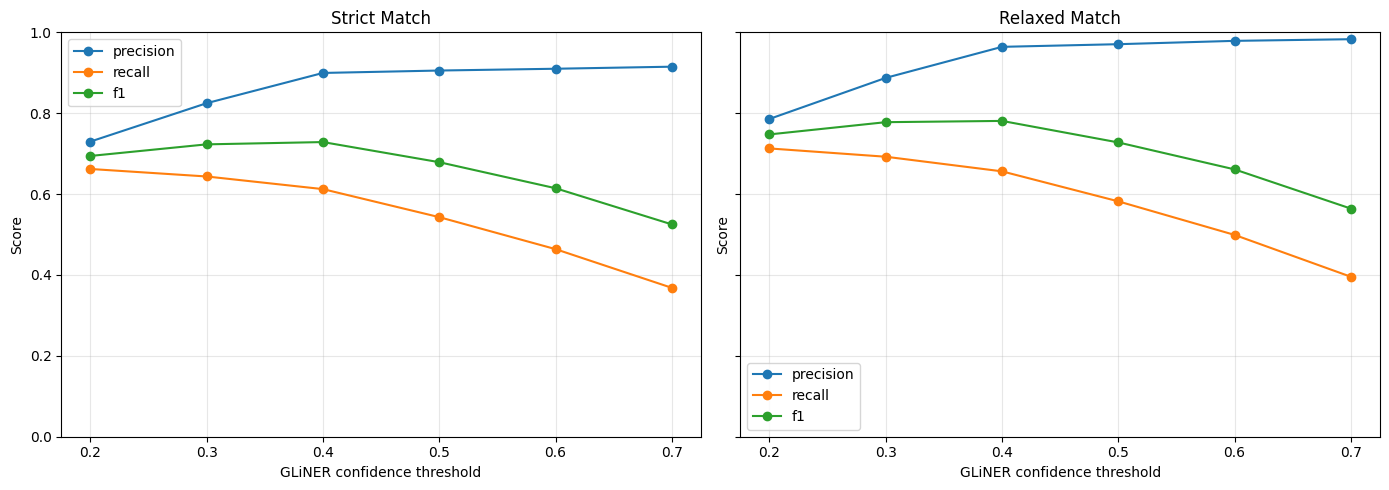

In [46]:
# Visualize GLiNER tuning metrics across thresholds.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for axis, mode in zip(axes, ["strict", "relaxed"]):
    mode_df = gliner_tuning_overall_df[gliner_tuning_overall_df["mode"] == mode]
    for metric in ["precision", "recall", "f1"]:
        axis.plot(
            mode_df["threshold"],
            mode_df[metric],
            marker="o",
            label=metric,
        )
    axis.set_title(f"{mode.title()} Match")
    axis.set_xlabel("GLiNER confidence threshold")
    axis.set_ylabel("Score")
    axis.set_ylim(0, 1)
    axis.grid(True, alpha=0.3)
    axis.legend()

plt.tight_layout()
plt.show()


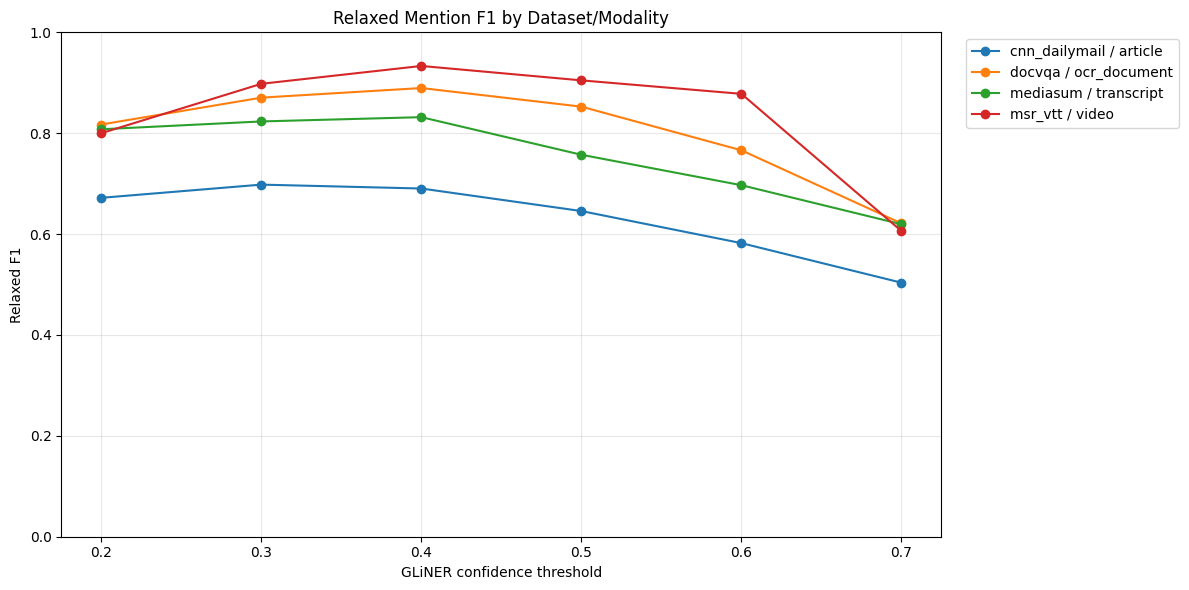

,threshold,dataset,modality,precision,recall,f1
6,0.2,cnn_dailymail,article,0.795213,0.581712,0.671910
16,0.3,cnn_dailymail,article,0.920382,0.562257,0.698068
26,0.4,cnn_dailymail,article,0.992701,0.529183,0.690355
36,0.5,cnn_dailymail,article,0.991935,0.478599,0.645669
46,0.6,cnn_dailymail,article,1.000000,0.410506,0.582069
56,0.7,cnn_dailymail,article,1.000000,0.336576,0.503639
7,0.2,docvqa,ocr_document,0.755869,0.889503,0.817259
17,0.3,docvqa,ocr_document,0.868132,0.872928,0.870523
27,0.4,docvqa,ocr_document,0.967532,0.823204,0.889552
37,0.5,docvqa,ocr_document,0.985507,0.751381,0.852665


In [47]:
# Visualize relaxed F1 by modality across thresholds.
gliner_tuning_modality_df = gliner_tuning_results_df[
    (gliner_tuning_results_df["scope"] == "dataset_modality")
    & (gliner_tuning_results_df["mode"] == "relaxed")
].copy()
gliner_tuning_modality_df["dataset_modality"] = (
    gliner_tuning_modality_df["dataset"]
    + " / "
    + gliner_tuning_modality_df["modality"]
)

fig, axis = plt.subplots(figsize=(12, 6))
for name, group_df in gliner_tuning_modality_df.groupby("dataset_modality"):
    group_df = group_df.sort_values("threshold")
    axis.plot(
        group_df["threshold"],
        group_df["f1"],
        marker="o",
        label=name,
    )
axis.set_title("Relaxed Mention F1 by Dataset/Modality")
axis.set_xlabel("GLiNER confidence threshold")
axis.set_ylabel("Relaxed F1")
axis.set_ylim(0, 1)
axis.grid(True, alpha=0.3)
axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

gliner_tuning_modality_df[[
    "threshold",
    "dataset",
    "modality",
    "precision",
    "recall",
    "f1",
]].sort_values(["dataset", "modality", "threshold"])


In [48]:
# Select the threshold that maximizes relaxed F1, preferring recall for ties.
best_gliner_threshold_row = gliner_tuning_overall_df[
    gliner_tuning_overall_df["mode"] == "relaxed"
].sort_values(
    ["f1", "recall", "precision"],
    ascending=False,
).iloc[0]

BEST_GLINER_MENTION_THRESHOLD = float(best_gliner_threshold_row["threshold"])
MENTION_CONFIDENCE_THRESHOLD = BEST_GLINER_MENTION_THRESHOLD

best_gliner_threshold_row


tp                672
fp                 25
fn                352
predicted         697
gold             1024
chunks             60
precision    0.964132
recall        0.65625
f1           0.780941
mode          relaxed
threshold         0.4
scope         overall
dataset           NaN
modality          NaN
Name: 25, dtype: object

In [49]:
# Evaluate GLiNER mention extraction on the corrected test gold set.
MENTION_GOLD_TEST_JSONL = Path("data") / "evaluation" / "mention_extraction" / "mention_gold_test.jsonl"
MENTION_GOLD_TEST_PREFILL_JSONL = Path("data") / "evaluation" / "mention_extraction" / "mention_gold_test_prefill.jsonl"
GLINER_TEST_THRESHOLD = 0.4

mention_gold_test_df = jsonl_to_dataframe(MENTION_GOLD_TEST_JSONL)
mention_gold_test_records = mention_gold_test_df.to_dict(orient="records")
mention_test_prefill_df = jsonl_to_dataframe(MENTION_GOLD_TEST_PREFILL_JSONL)

gliner_test_predictions_by_chunk_id = {
    row["chunk_id"]: row.get("predicted_mentions") or []
    for _, row in mention_test_prefill_df.iterrows()
}
gliner_test_predictions_at_threshold = filter_predictions_by_score(
    gliner_test_predictions_by_chunk_id,
    GLINER_TEST_THRESHOLD,
)

gliner_test_relaxed_metrics_by_dataset_modality_df = evaluate_mention_records(
    records=mention_gold_test_records,
    predictions_by_chunk_id=gliner_test_predictions_at_threshold,
    mode="relaxed",
    group_fields=["dataset", "modality"],
    require_label_match=True,
).sort_values(["dataset", "modality"]).reset_index(drop=True)
gliner_test_relaxed_metrics_by_dataset_modality_df["threshold"] = GLINER_TEST_THRESHOLD

gliner_test_relaxed_metrics_by_dataset_modality_df[[
    "threshold",
    "dataset",
    "modality",
    "chunks",
    "predicted",
    "gold",
    "tp",
    "fp",
    "fn",
    "precision",
    "recall",
    "f1",
]]


,threshold,dataset,modality,chunks,predicted,gold,tp,fp,fn,precision,recall,f1
0,0.4,cnn_dailymail,article,30,629,656,626,3,30,0.995231,0.954268,0.974319
1,0.4,docvqa,ocr_document,30,277,317,276,1,41,0.996390,0.870662,0.929293
2,0.4,mediasum,transcript,30,631,640,631,0,9,1.000000,0.985938,0.992919
3,0.4,msr_vtt,video,30,49,49,48,1,1,0.979592,0.979592,0.979592


In [50]:
# Build relaxed mismatch detail and summary tables for test error analysis.
gliner_test_relaxed_mismatch_df = collect_mention_mismatches(
    records=mention_gold_test_records,
    predictions_by_chunk_id=gliner_test_predictions_at_threshold,
    mode="relaxed",
    require_label_match=True,
)

gliner_test_mismatch_type_label_df = summarize_mention_mismatches(
    gliner_test_relaxed_mismatch_df,
    group_fields=["mismatch_type", "label"],
)
gliner_test_mismatch_type_dataset_df = summarize_mention_mismatches(
    gliner_test_relaxed_mismatch_df,
    group_fields=["dataset", "modality", "mismatch_type"],
)

display(gliner_test_mismatch_type_label_df.head(40))
display(gliner_test_mismatch_type_dataset_df)


,mismatch_type,label,count
0,MISSING_GOLD,DATE,59
1,MISSING_GOLD,CREATIVE_WORK,6
2,MISSING_GOLD,PRODUCT,5
3,LABEL_MISMATCH,ORGANIZATION -> POLITICAL_GROUP,3
4,MISSING_GOLD,ORGANIZATION,3
5,LABEL_MISMATCH,CREATIVE_WORK -> RELIGION,1
6,LABEL_MISMATCH,ORGANIZATION -> LOCATION,1
7,MISSING_GOLD,LAW,1
8,MISSING_GOLD,LOCATION,1
9,MISSING_GOLD,PERSON,1


,dataset,modality,mismatch_type,count
0,docvqa,ocr_document,MISSING_GOLD,40
1,cnn_dailymail,article,MISSING_GOLD,27
2,mediasum,transcript,MISSING_GOLD,9
3,cnn_dailymail,article,LABEL_MISMATCH,3
4,docvqa,ocr_document,LABEL_MISMATCH,1
5,msr_vtt,video,LABEL_MISMATCH,1


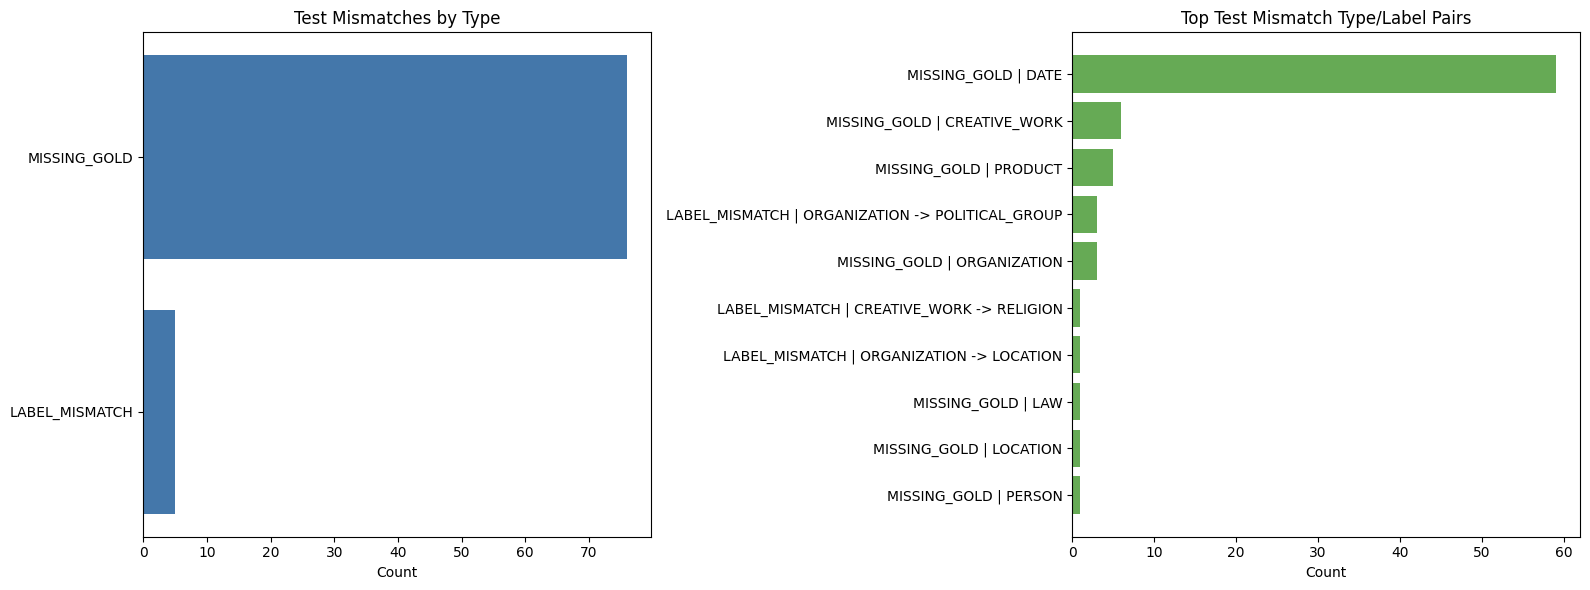

In [51]:
# Visualize test mismatches by type and label.
if gliner_test_relaxed_mismatch_df.empty:
    print("No relaxed mention mismatches at threshold 0.4.")
else:
    mismatch_type_counts_df = summarize_mention_mismatches(
        gliner_test_relaxed_mismatch_df,
        group_fields=["mismatch_type"],
    )
    mismatch_label_counts_df = gliner_test_mismatch_type_label_df.head(25).copy()
    mismatch_label_counts_df["type_label"] = (
        mismatch_label_counts_df["mismatch_type"]
        + " | "
        + mismatch_label_counts_df["label"].astype(str)
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].barh(
        mismatch_type_counts_df["mismatch_type"],
        mismatch_type_counts_df["count"],
        color="#4477AA",
    )
    axes[0].invert_yaxis()
    axes[0].set_title("Test Mismatches by Type")
    axes[0].set_xlabel("Count")

    axes[1].barh(
        mismatch_label_counts_df["type_label"],
        mismatch_label_counts_df["count"],
        color="#66AA55",
    )
    axes[1].invert_yaxis()
    axes[1].set_title("Top Test Mismatch Type/Label Pairs")
    axes[1].set_xlabel("Count")
    plt.tight_layout()
    plt.show()

    gliner_test_relaxed_mismatch_df.sort_values(
        ["dataset", "modality", "mismatch_type", "label", "chunk_id"],
    ).head(30)


#### 4.2.2. Run Mention Extraction on Selected Chunks

Apply the tuned mention extractor to `chunks_to_index`, then export `Mention` nodes and `Chunk`-to-`Mention` relationships for graph import.


In [52]:
if "chunks_to_index" not in globals():
    raise RuntimeError("Run the Qdrant chunk-selection cell before mention extraction.")

if MAX_CHUNKS_FOR_MENTION_EXTRACTION is not None:
    chunks_for_mention_extraction = chunks_to_index[:MAX_CHUNKS_FOR_MENTION_EXTRACTION]
else:
    chunks_for_mention_extraction = chunks_to_index

print(f"Chunks selected for mention extraction: {len(chunks_for_mention_extraction):,}")


Chunks selected for mention extraction: 297,016


In [53]:
mention_predictions_by_chunk_id = run_mention_extraction(
    chunks=chunks_for_mention_extraction,
    model=gliner_mention_model,
    labels=MENTION_LABELS,
    threshold=MENTION_CONFIDENCE_THRESHOLD,
)

mention_tables = build_mention_tables(
    chunks_for_mention_extraction,
    mention_predictions_by_chunk_id,
    extractor=MENTION_EXTRACTOR_NAME,
    model_name=GLINER_MODEL_NAME,
    label_set_version=MENTION_LABEL_SET_VERSION,
)
mention_export_paths = export_mention_tables(mention_tables, MENTION_EXPORT_DIR)

mention_export_summary = pd.DataFrame(
    [
        {
            "table": table_name,
            "rows": len(table),
            "csv_path": str(mention_export_paths[table_name]),
        }
        for table_name, table in mention_tables.items()
    ]
).sort_values("table")

mention_export_summary


Extracting mentions with GLiNER:   0%|          | 0/297016 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
mention_tables["mentions"].head()


,mention_id:ID(Mention),mention_text,mention_type,chunk_id,document_id,dataset,modality,start_char:int,end_char:int,confidence:float,extractor,model_name,label_set_version,sensitivity_level,access_level,:LABEL
0,09135c52e49d3e80e2b23f8d,Forest Whitaker,PERSON,016ab6e11ff9ec666f56855b,5c7aa6d2035899720d170b77,mediasum,transcript,37,52,0.804996,GLiNER,urchade/gliner_medium-v2.1,v1,S0,public,Mention
1,4836dd3551d8f9062080e443,Tisha Campbell Martin,PERSON,016ab6e11ff9ec666f56855b,5c7aa6d2035899720d170b77,mediasum,transcript,63,84,0.747157,GLiNER,urchade/gliner_medium-v2.1,v1,S0,public,Mention
2,98f5ab0fe76dda0e29d6fafc,The Bible Experience,PRODUCT,016ab6e11ff9ec666f56855b,5c7aa6d2035899720d170b77,mediasum,transcript,126,146,0.663542,GLiNER,urchade/gliner_medium-v2.1,v1,S0,public,Mention
3,45af1ad28020193715ed2b98,The Complete Bible,WORK_OF_ART,016ab6e11ff9ec666f56855b,5c7aa6d2035899720d170b77,mediasum,transcript,222,240,0.672786,GLiNER,urchade/gliner_medium-v2.1,v1,S0,public,Mention
4,6557b1d03577fe78e905c63c,Blair Underwood,PERSON,016ab6e11ff9ec666f56855b,5c7aa6d2035899720d170b77,mediasum,transcript,418,433,0.758113,GLiNER,urchade/gliner_medium-v2.1,v1,S0,public,Mention


In [ ]:
# Build model-assisted mention gold dev/test prefill files.
# This temporary cell starts from chunks_to_index, samples mixed cases, runs GLiNER only
# on the selected chunks, and writes JSONL files that can be manually corrected into gold labels.
MENTION_GOLD_DIR = Path("data") / "evaluation" / "mention_extraction"
MENTION_GOLD_DEV_JSONL = MENTION_GOLD_DIR / "mention_gold_dev_prefill.jsonl"
MENTION_GOLD_TEST_JSONL = MENTION_GOLD_DIR / "mention_gold_test_prefill.jsonl"
MENTION_GOLD_DEV_CHUNKS_PER_DATASET = 15
MENTION_GOLD_TEST_CHUNKS_PER_DATASET = 30
MENTION_GOLD_RANDOM_SEED = RANDOM_SEED
MENTION_GOLD_CASE_ORDER = [
    "short",
    "long",
    "entity_rich",
    "entity_poor",
    "noisy",
    "dialogue_heavy",
    "caption_style",
]


def _gold_chunk_text(chunk: ArchiveChunk) -> str:
    return chunk.masked_text or chunk.raw_text or ""


def _line_ratio(text: str, predicate: Any) -> float:
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    if not lines:
        return 0.0
    return sum(1 for line in lines if predicate(line)) / len(lines)


def _estimated_entity_signal_count(text: str) -> int:
    capitalized_phrases = re.findall(r"\b[A-Z][a-z]+(?:\s+[A-Z][a-z]+){0,4}\b", text)
    years = re.findall(r"\b(?:19|20)\d{2}\b", text)
    dates = re.findall(r"\b(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*\.?\s+\d{1,2}(?:,\s*\d{4})?\b", text, flags=re.IGNORECASE)
    org_markers = re.findall(r"\b(?:Inc|Corp|Corporation|University|Institute|Ministry|Department|Agency|Committee|Court|Hospital|Bank)\b", text)
    return len(capitalized_phrases) + len(years) + len(dates) + len(org_markers)


def _build_mention_gold_candidate_frame(chunks: List[ArchiveChunk]) -> pd.DataFrame:
    rows = []
    for chunk in chunks:
        text = _gold_chunk_text(chunk)
        words = text.split()
        alpha_chars = sum(1 for char in text if char.isalpha())
        non_space_chars = sum(1 for char in text if not char.isspace())
        rows.append(
            {
                "chunk_id": chunk.chunk_id,
                "document_id": chunk.document_id,
                "source_id": chunk.source_id,
                "dataset": chunk.dataset,
                "modality": chunk.modality,
                "chunk_index": chunk.chunk_index,
                "title": chunk.title,
                "text": text,
                "word_count": len(words),
                "char_count": len(text),
                "entity_signal_count": _estimated_entity_signal_count(text),
                "alpha_ratio": alpha_chars / non_space_chars if non_space_chars else 0.0,
                "colon_line_ratio": _line_ratio(text, lambda line: ":" in line and len(line.split(":", 1)[0].split()) <= 8),
                "caption_line_ratio": _line_ratio(text, lambda line: bool(re.search(r"^(segment\s+\d+\s+)?\[?\d+(?:\.\d+)?s?[-–]\d+(?:\.\d+)?s?\]?\s*:", line, flags=re.IGNORECASE))),
                "layout_line_ratio": _line_ratio(text, lambda line: bool(re.search(r"^(ocr\s+)?(line|block|region)\s+\d+", line, flags=re.IGNORECASE))),
            }
        )

    candidate_df = pd.DataFrame(rows)
    if candidate_df.empty:
        return candidate_df

    candidate_df["word_q25"] = candidate_df.groupby("dataset")["word_count"].transform(lambda values: values.quantile(0.25))
    candidate_df["word_q75"] = candidate_df.groupby("dataset")["word_count"].transform(lambda values: values.quantile(0.75))
    candidate_df["entity_q25"] = candidate_df.groupby("dataset")["entity_signal_count"].transform(lambda values: values.quantile(0.25))
    candidate_df["entity_q75"] = candidate_df.groupby("dataset")["entity_signal_count"].transform(lambda values: values.quantile(0.75))

    def classify_cases(row: pd.Series) -> List[str]:
        cases = []
        if row.word_count <= row.word_q25:
            cases.append("short")
        if row.word_count >= row.word_q75:
            cases.append("long")
        if row.entity_signal_count >= max(3, row.entity_q75):
            cases.append("entity_rich")
        if row.entity_signal_count <= row.entity_q25:
            cases.append("entity_poor")
        if row.dataset == DatasetName.DOCVQA.value or row.modality == Modality.OCR_DOCUMENT.value or row.layout_line_ratio >= 0.25 or row.alpha_ratio < 0.65 or "OCR text unavailable" in row.text:
            cases.append("noisy")
        if row.dataset == DatasetName.MEDIASUM.value or row.modality == Modality.TRANSCRIPT.value:
            if row.colon_line_ratio >= 0.30:
                cases.append("dialogue_heavy")
        if row.dataset == DatasetName.MSR_VTT.value or row.modality == Modality.VIDEO.value:
            if row.caption_line_ratio >= 0.30 or "Segment " in row.text:
                cases.append("caption_style")
        return cases or ["regular"]

    candidate_df["sampling_cases"] = candidate_df.apply(classify_cases, axis=1)
    return candidate_df


def _select_mixed_gold_candidates(candidate_df: pd.DataFrame, per_dataset: int, random_seed: int) -> pd.DataFrame:
    rng = random.Random(random_seed)
    selected_rows = []
    selected_chunk_ids = set()

    for dataset, dataset_df in candidate_df.groupby("dataset", sort=True):
        dataset_rows = dataset_df.to_dict(orient="records")
        dataset_selected = []

        while len(dataset_selected) < min(per_dataset, len(dataset_rows)):
            progressed = False
            for case_name in MENTION_GOLD_CASE_ORDER:
                pool = [
                    row
                    for row in dataset_rows
                    if row["chunk_id"] not in selected_chunk_ids
                    and row["chunk_id"] not in {item["chunk_id"] for item in dataset_selected}
                    and case_name in row["sampling_cases"]
                ]
                if not pool:
                    continue
                dataset_selected.append(rng.choice(pool))
                progressed = True
                if len(dataset_selected) >= min(per_dataset, len(dataset_rows)):
                    break
            if not progressed:
                remaining = [
                    row
                    for row in dataset_rows
                    if row["chunk_id"] not in selected_chunk_ids
                    and row["chunk_id"] not in {item["chunk_id"] for item in dataset_selected}
                ]
                if not remaining:
                    break
                rng.shuffle(remaining)
                dataset_selected.extend(remaining[: per_dataset - len(dataset_selected)])

        selected_rows.extend(dataset_selected[:per_dataset])
        selected_chunk_ids.update(row["chunk_id"] for row in dataset_selected[:per_dataset])

    return pd.DataFrame(selected_rows)


if "chunks_to_index" not in globals():
    raise RuntimeError("Run the Qdrant chunk-selection cell before building mention gold files.")

candidate_df = _build_mention_gold_candidate_frame(chunks_to_index)
dev_candidates_df = _select_mixed_gold_candidates(
    candidate_df,
    per_dataset=MENTION_GOLD_DEV_CHUNKS_PER_DATASET,
    random_seed=MENTION_GOLD_RANDOM_SEED,
)
remaining_candidate_df = candidate_df[~candidate_df["chunk_id"].isin(dev_candidates_df["chunk_id"])]
test_candidates_df = _select_mixed_gold_candidates(
    remaining_candidate_df,
    per_dataset=MENTION_GOLD_TEST_CHUNKS_PER_DATASET,
    random_seed=MENTION_GOLD_RANDOM_SEED + 1,
)

sampled_chunk_ids = set(dev_candidates_df["chunk_id"]) | set(test_candidates_df["chunk_id"])
chunks_by_id = {chunk.chunk_id: chunk for chunk in chunks_to_index if chunk.chunk_id in sampled_chunk_ids}
sampled_chunks = [chunks_by_id[chunk_id] for chunk_id in sorted(sampled_chunk_ids) if chunk_id in chunks_by_id]

gold_prefill_predictions_by_chunk_id = run_mention_extraction(
    chunks=sampled_chunks,
    model=gliner_mention_model,
    labels=MENTION_LABELS,
    threshold=MENTION_CONFIDENCE_THRESHOLD,
)

def _build_gold_prefill_records(candidate_subset_df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    records = []
    for row in candidate_subset_df.to_dict(orient="records"):
        predicted_mentions = gold_prefill_predictions_by_chunk_id.get(row["chunk_id"], [])
        records.append(
            {
                "split": split_name,
                "chunk_id": row["chunk_id"],
                "document_id": row["document_id"],
                "source_id": row["source_id"],
                "dataset": row["dataset"],
                "modality": row["modality"],
                "chunk_index": row["chunk_index"],
                "title": row["title"],
                "text": row["text"],
                "sampling_cases": row["sampling_cases"],
                "predicted_mentions": predicted_mentions,
                "mentions": [dict(mention) for mention in predicted_mentions],
            }
        )
    return pd.DataFrame(records)

dev_gold_prefill_df = _build_gold_prefill_records(dev_candidates_df, "dev")
test_gold_prefill_df = _build_gold_prefill_records(test_candidates_df, "test")

dataframe_to_jsonl(dev_gold_prefill_df, MENTION_GOLD_DEV_JSONL)
dataframe_to_jsonl(test_gold_prefill_df, MENTION_GOLD_TEST_JSONL)

mention_gold_summary = pd.concat([dev_gold_prefill_df, test_gold_prefill_df]).explode("sampling_cases")
mention_gold_summary = mention_gold_summary.groupby(["split", "dataset", "sampling_cases"]).size().reset_index(name="chunks")
mention_gold_summary


Extracting mentions with GLiNER:   0%|          | 0/180 [00:00<?, ?it/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\gliner\data_processing\processor.py:395: UserWarning: Sentence of length 408 has been truncated to 384
  batch = [self.preprocess_example(b["tokenized_text"], b[key], class_to_ids) for b in batch_list]
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\gliner\data_processing\processor.py:395: UserWarning: Sentence of length 571 has been truncated to 384
  batch = [self.preprocess_example(b["tokenized_text"], b[key], class_to_ids) for b in batch_list]
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\gliner\data_processing\processor.py:39

NameError: name 'dataframe_to_jsonl' is not defined

In [59]:
# Compare predicted mentions against corrected gold mentions.
MENTION_GOLD_DEV_JSONL = Path("data") / "evaluation" / "mention_extraction" / "mention_gold_dev.jsonl"
MENTION_GOLD_TEST_JSONL = Path("data") / "evaluation" / "mention_extraction" / "mention_gold_test.jsonl"

def _mention_key(mention: Dict[str, Any]) -> Tuple[Any, Any, Any, Any]:
    return (
        mention.get("start"),
        mention.get("end"),
        mention.get("label"),
        mention.get("text"),
    )


def _mention_span_key(mention: Dict[str, Any]) -> Tuple[Any, Any, Any]:
    return (
        mention.get("start"),
        mention.get("end"),
        mention.get("text"),
    )


def compare_predicted_and_gold_mentions(gold_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    chunk_rows = []
    diff_rows = []

    for record in gold_df.to_dict(orient="records"): 
        predicted_mentions = record.get("predicted_mentions") or []
        gold_mentions = record.get("mentions") or []

        predicted_by_key = {_mention_key(mention): mention for mention in predicted_mentions}
        gold_by_key = {_mention_key(mention): mention for mention in gold_mentions}
        predicted_keys = set(predicted_by_key)
        gold_keys = set(gold_by_key)

        exact_match_keys = predicted_keys & gold_keys
        removed_keys = predicted_keys - gold_keys
        added_keys = gold_keys - predicted_keys

        predicted_by_span = {_mention_span_key(mention): mention for mention in predicted_mentions}
        gold_by_span = {_mention_span_key(mention): mention for mention in gold_mentions}
        label_change_spans = set(predicted_by_span) & set(gold_by_span)
        label_changes = [
            span_key
            for span_key in label_change_spans
            if predicted_by_span[span_key].get("label") != gold_by_span[span_key].get("label")
        ]

        chunk_rows.append(
            {
                "split": record.get("split"),
                "chunk_id": record.get("chunk_id"),
                "dataset": record.get("dataset"),
                "modality": record.get("modality"),
                "predicted_count": len(predicted_mentions),
                "gold_count": len(gold_mentions),
                "exact_match_count": len(exact_match_keys),
                "added_gold_count": len(added_keys),
                "removed_prediction_count": len(removed_keys),
                "label_change_count": len(label_changes),
            }
        )

        for key in sorted(added_keys):
            mention = gold_by_key[key]
            diff_rows.append(
                {
                    "split": record.get("split"),
                    "chunk_id": record.get("chunk_id"),
                    "dataset": record.get("dataset"),
                    "diff_type": "added_gold",
                    "text": mention.get("text"),
                    "label": mention.get("label"),
                    "start": mention.get("start"),
                    "end": mention.get("end"),
                }
            )

        for key in sorted(removed_keys):
            mention = predicted_by_key[key]
            diff_rows.append(
                {
                    "split": record.get("split"),
                    "chunk_id": record.get("chunk_id"),
                    "dataset": record.get("dataset"),
                    "diff_type": "removed_prediction",
                    "text": mention.get("text"),
                    "label": mention.get("label"),
                    "start": mention.get("start"),
                    "end": mention.get("end"),
                    "score": mention.get("score"),
                }
            )

        for span_key in sorted(label_changes):
            predicted = predicted_by_span[span_key]
            gold = gold_by_span[span_key]
            diff_rows.append(
                {
                    "split": record.get("split"),
                    "chunk_id": record.get("chunk_id"),
                    "dataset": record.get("dataset"),
                    "diff_type": "label_changed",
                    "text": gold.get("text"),
                    "predicted_label": predicted.get("label"),
                    "gold_label": gold.get("label"),
                    "start": gold.get("start"),
                    "end": gold.get("end"),
                    "score": predicted.get("score"),
                }
            )

    return pd.DataFrame(chunk_rows), pd.DataFrame(diff_rows)


mention_gold_df = pd.concat(
    [
        jsonl_to_dataframe(MENTION_GOLD_DEV_JSONL),
        jsonl_to_dataframe(MENTION_GOLD_TEST_JSONL),
    ],
    ignore_index=True,
)
mention_gold_chunk_diff_df, mention_gold_detail_diff_df = compare_predicted_and_gold_mentions(mention_gold_df)

mention_gold_diff_summary = mention_gold_chunk_diff_df.groupby(["split", "dataset"]).agg(
    chunks=("chunk_id", "count"),
    predicted_mentions=("predicted_count", "sum"),
    gold_mentions=("gold_count", "sum"),
    exact_matches=("exact_match_count", "sum"),
    added_gold_mentions=("added_gold_count", "sum"),
    removed_predictions=("removed_prediction_count", "sum"),
    label_changes=("label_change_count", "sum"),
).reset_index()

mention_gold_diff_summary


,split,dataset,chunks,predicted_mentions,gold_mentions,exact_matches,added_gold_mentions,removed_predictions,label_changes
0,dev,cnn_dailymail,15,170,465,151,314,19,5
1,dev,docvqa,15,78,106,30,76,48,6
2,dev,mediasum,15,171,289,144,145,27,5
3,dev,msr_vtt,15,22,16,0,16,22,0
4,test,cnn_dailymail,30,408,436,376,60,32,0
5,test,docvqa,30,169,269,152,117,17,0
6,test,mediasum,30,420,407,389,18,31,1
7,test,msr_vtt,30,46,36,5,31,41,1
